# Data Cleaning

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/goals.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      461 non-null    object
 1   Unnamed: 1      461 non-null    object
 2   Unnamed: 2      461 non-null    object
 3   Unnamed: 3      461 non-null    object
 4   Unnamed: 4      461 non-null    object
 5   Unnamed: 5      461 non-null    object
 6   Unnamed: 6      461 non-null    object
 7   Unnamed: 7      461 non-null    object
 8   Unnamed: 8      461 non-null    object
 9   Playing Time    461 non-null    object
 10  Playing Time.1  461 non-null    object
 11  Playing Time.2  461 non-null    object
 12  Playing Time.3  461 non-null    object
 13  Playing Time.4  461 non-null    object
 14  Playing Time.5  461 non-null    object
 15  Performance     461 non-null    object
 16  Performance.1   461 non-null    object
 17  Performance.2   461 non-null    object
 18  Performanc

In [ ]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Playing Time,...,Playing Time.5,Performance,Performance.1,Performance.2,Performance.3,Performance.4,Performance.5,Performance.6,Unnamed: 22,-additional
0,Rk,Player,Gls,Min,Season,Age,Nation,Team,Comp,MP,...,unSub,Gls,Ast,G+A,G-PK,PK,PKatt,PKm,Pos,-9999
1,1,Kylian Mbappé,31,2907,2024-2025,25,fr FRA,Real Madrid,es La Liga,34,...,0,31,3,34,24,7,9,2,FW,42fd9c7f
2,2,Mohamed Salah,29,3371,2024-2025,32,eg EGY,Liverpool,eng Premier League,38,...,0,29,18,47,20,9,9,0,FW,e342ad68
3,3,Robert Lewandowski,27,2667,2024-2025,35,pl POL,Barcelona,es La Liga,34,...,2,27,2,29,24,3,4,1,FW,8d78e732
4,4,Harry Kane,26,2381,2024-2025,31,eng ENG,Bayern Munich,de Bundesliga,31,...,0,26,9,35,17,9,9,0,FW,21a66f6a


In [ ]:
import pandas as pd

# Load the CSV, skipping the first row (metadata) and using the second row as headers
df = pd.read_csv("/content/goals.csv", skiprows=1)

# Display the first few rows and column names to confirm
print("Column Names:")
print(df.columns.tolist())
print("\nData Preview:")
print(df.head())

Column Names:
['Rk', 'Player', 'Gls', 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Min.1', '90s', 'Starts', 'Subs', 'unSub', 'Gls.1', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Pos', '-9999']

Data Preview:
   Rk              Player  Gls   Min     Season  Age   Nation           Team  \
0   1       Kylian Mbappé   31  2907  2024-2025   25   fr FRA    Real Madrid   
1   2       Mohamed Salah   29  3371  2024-2025   32   eg EGY      Liverpool   
2   3  Robert Lewandowski   27  2667  2024-2025   35   pl POL      Barcelona   
3   4          Harry Kane   26  2381  2024-2025   31  eng ENG  Bayern Munich   
4   5       Mateo Retegui   25  2383  2024-2025   25   it ITA       Atalanta   

                 Comp  MP  ...  unSub  Gls.1  Ast  G+A  G-PK  PK  PKatt  PKm  \
0          es La Liga  34  ...      0     31    3   34    24   7      9    2   
1  eng Premier League  38  ...      0     29   18   47    20   9      9    0   
2          es La Liga  34  ...      2     27    2   29    

In [ ]:
# Check for duplicate columns
print("\nDuplicate Columns:")
print(df.columns[df.columns.duplicated()].tolist())

# Rename duplicate columns
df = df.rename(columns={
    'Gls': 'Goals',
    'Min': 'Total_Minutes',
    'Gls.1': 'Goals_Scored',
    'Min.1': 'Minutes_Per_90'
})

# Verify updated column names
print("\nUpdated Column Names:")
print(df.columns.tolist())


Duplicate Columns:
[]

Updated Column Names:
['Rk', 'Player', 'Goals', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Minutes_Per_90', '90s', 'Starts', 'Subs', 'unSub', 'Goals_Scored', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Pos', '-9999']


In [ ]:
# Define numeric columns
numeric_cols = ['Goals', 'Total_Minutes', 'Age', 'MP', '90s', 'Starts', 'Subs', 'unSub',
                'Goals_Scored', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm']

# Convert numeric columns
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Define categorical columns
categorical_cols = [col for col in df.columns if col not in numeric_cols]

# Convert categorical columns
df[categorical_cols] = df[categorical_cols].astype(str)

# Display info to confirm types
print("\nDataFrame Info After Type Conversion:")
print(df.info())
print("\nData Preview After Conversion:")
print(df.head())


DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rk              460 non-null    object 
 1   Player          460 non-null    object 
 2   Goals           460 non-null    int64  
 3   Total_Minutes   460 non-null    int64  
 4   Season          460 non-null    object 
 5   Age             460 non-null    int64  
 6   Nation          460 non-null    object 
 7   Team            460 non-null    object 
 8   Comp            460 non-null    object 
 9   MP              460 non-null    int64  
 10  Minutes_Per_90  460 non-null    object 
 11  90s             460 non-null    float64
 12  Starts          460 non-null    int64  
 13  Subs            460 non-null    int64  
 14  unSub           460 non-null    int64  
 15  Goals_Scored    460 non-null    int64  
 16  Ast             460 non-null    int64  
 

In [ ]:
print("\nMinimum Minutes:")
print(df['Total_Minutes'].min())


Minimum Minutes:
1003


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())
df[numeric_cols] = df[numeric_cols].fillna(0)  # Or drop rows with df.dropna()


Missing Values:
Rk                0
Player            0
Goals             0
Total_Minutes     0
Season            0
Age               0
Nation            0
Team              0
Comp              0
MP                0
Minutes_Per_90    0
90s               0
Starts            0
Subs              0
unSub             0
Goals_Scored      0
Ast               0
G+A               0
G-PK              0
PK                0
PKatt             0
PKm               0
Pos               0
-9999             0
dtype: int64


In [ ]:
# Convert Minutes_Per_90 to numeric
df['Minutes_Per_90'] = pd.to_numeric(df['Minutes_Per_90'], errors='coerce')

# Verify the change
print("\nUpdated DataFrame Info:")
print(df.info())


Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rk              460 non-null    object 
 1   Player          460 non-null    object 
 2   Goals           460 non-null    int64  
 3   Total_Minutes   460 non-null    int64  
 4   Season          460 non-null    object 
 5   Age             460 non-null    int64  
 6   Nation          460 non-null    object 
 7   Team            460 non-null    object 
 8   Comp            460 non-null    object 
 9   MP              460 non-null    int64  
 10  Minutes_Per_90  460 non-null    int64  
 11  90s             460 non-null    float64
 12  Starts          460 non-null    int64  
 13  Subs            460 non-null    int64  
 14  unSub           460 non-null    int64  
 15  Goals_Scored    460 non-null    int64  
 16  Ast             460 non-null    int64  
 17  G+A       

In [ ]:
print("\nComparison of Goals and Goals_Scored:")
print(df[['Goals', 'Goals_Scored']].head())
print("\nComparison of Total_Minutes and Minutes_Per_90:")
print(df[['Total_Minutes', 'Minutes_Per_90']].head())


Comparison of Goals and Goals_Scored:
   Goals  Goals_Scored
0     31            31
1     29            29
2     27            27
3     26            26
4     25            25

Comparison of Total_Minutes and Minutes_Per_90:
   Total_Minutes  Minutes_Per_90
0           2907            2907
1           3371            3371
2           2667            2667
3           2381            2381
4           2383            2383


In [ ]:
import pandas as pd

# Assuming df is the current DataFrame
df = df.drop(columns=['Goals_Scored', 'Minutes_Per_90'])

# Verify the dropped columns
print("\nColumn Names After Dropping Redundancies:")
print(df.columns.tolist())


Column Names After Dropping Redundancies:
['Rk', 'Player', 'Goals', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', '90s', 'Starts', 'Subs', 'unSub', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Pos', '-9999']


In [ ]:
# Rename columns for consistency
df = df.rename(columns={
    'Gls': 'Goals',
    'Min': 'Total_Minutes',
    'Ast': 'Assists',
    'G+A': 'Goals_Assists',
    'G-PK': 'Non_Penalty_Goals',
    'PK': 'Penalties_Made',
    'PKatt': 'Penalties_Attempted',
    'PKm': 'Penalties_Missed',
    'Pos': 'Position',
    '-9999': 'Player_ID'
})

# Verify the updated column names
print("\nUpdated Column Names:")
print(df.columns.tolist())


Updated Column Names:
['Rk', 'Player', 'Goals', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', '90s', 'Starts', 'Subs', 'unSub', 'Assists', 'Goals_Assists', 'Non_Penalty_Goals', 'Penalties_Made', 'Penalties_Attempted', 'Penalties_Missed', 'Position', 'Player_ID']


In [ ]:
print("\nData Preview After Renaming:")
print(df.head())

# Verify 90s matches Total_Minutes / 90
print("\nVerification of 90s:")
print(df[['Total_Minutes', '90s']].head())


Data Preview After Renaming:
  Rk              Player  Goals  Total_Minutes     Season  Age   Nation  \
0  1       Kylian Mbappé     31           2907  2024-2025   25   fr FRA   
1  2       Mohamed Salah     29           3371  2024-2025   32   eg EGY   
2  3  Robert Lewandowski     27           2667  2024-2025   35   pl POL   
3  4          Harry Kane     26           2381  2024-2025   31  eng ENG   
4  5       Mateo Retegui     25           2383  2024-2025   25   it ITA   

            Team                Comp  MP  ...  Subs  unSub  Assists  \
0    Real Madrid          es La Liga  34  ...     0      0        3   
1      Liverpool  eng Premier League  38  ...     0      0       18   
2      Barcelona          es La Liga  34  ...     2      2        2   
3  Bayern Munich       de Bundesliga  31  ...     3      0        9   
4       Atalanta          it Serie A  36  ...     4      0        8   

   Goals_Assists  Non_Penalty_Goals  Penalties_Made  Penalties_Attempted  \
0             34

In [ ]:
df.to_csv("/content/goals.csv", index=False)

print("\nDataset Saved Successfully!")
print("Final Column Names:")
print(df.columns.tolist())
print("\nFinal Data Preview:")
print(df.head())


Dataset Saved Successfully!
Final Column Names:
['Rk', 'Player', 'Goals', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', '90s', 'Starts', 'Subs', 'unSub', 'Assists', 'Goals_Assists', 'Non_Penalty_Goals', 'Penalties_Made', 'Penalties_Attempted', 'Penalties_Missed', 'Position', 'Player_ID']

Final Data Preview:
  Rk              Player  Goals  Total_Minutes     Season  Age   Nation  \
0  1       Kylian Mbappé     31           2907  2024-2025   25   fr FRA   
1  2       Mohamed Salah     29           3371  2024-2025   32   eg EGY   
2  3  Robert Lewandowski     27           2667  2024-2025   35   pl POL   
3  4          Harry Kane     26           2381  2024-2025   31  eng ENG   
4  5       Mateo Retegui     25           2383  2024-2025   25   it ITA   

            Team                Comp  MP  ...  Subs  unSub  Assists  \
0    Real Madrid          es La Liga  34  ...     0      0        3   
1      Liverpool  eng Premier League  38  ...     0      0       18   
2    

In [ ]:
print(df.head())
print(df.info())
print(df.describe())

  Rk              Player  Goals  Total_Minutes     Season  Age   Nation  \
0  1       Kylian Mbappé     31           2907  2024-2025   25   fr FRA   
1  2       Mohamed Salah     29           3371  2024-2025   32   eg EGY   
2  3  Robert Lewandowski     27           2667  2024-2025   35   pl POL   
3  4          Harry Kane     26           2381  2024-2025   31  eng ENG   
4  5       Mateo Retegui     25           2383  2024-2025   25   it ITA   

            Team                Comp  MP  ...  Subs  unSub  Assists  \
0    Real Madrid          es La Liga  34  ...     0      0        3   
1      Liverpool  eng Premier League  38  ...     0      0       18   
2      Barcelona          es La Liga  34  ...     2      2        2   
3  Bayern Munich       de Bundesliga  31  ...     3      0        9   
4       Atalanta          it Serie A  36  ...     4      0        8   

   Goals_Assists  Non_Penalty_Goals  Penalties_Made  Penalties_Attempted  \
0             34                 24           

In [ ]:
import pandas as pd

# Reload the raw CSV
df_expected = pd.read_csv("/content/xg_stats.csv")

# Set the first row as column names and drop it
df_expected.columns = df_expected.iloc[0]
df_expected = df_expected.drop(0).reset_index(drop=True)

# Select relevant columns
df_expected = df_expected[['Rk', 'Player', 'xG', 'npxG', 'xAG', 'npxG/Sh', 'Min', 'Season', 'Age',
                          'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']]

# Check for duplicates immediately
print("Initial Column Names:")
print(df_expected.columns.tolist())
print("\nCheck for Duplicate Columns Before Renaming:")
print(df_expected.columns[df_expected.columns.duplicated()].tolist())

# Remove duplicates by keeping the first occurrence
if df_expected.columns.duplicated().any():
    df_expected = df_expected.loc[:, ~df_expected.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_expected.columns.tolist())

# Rename columns
df_expected = df_expected.rename(columns={
    'xG': 'Expected_Goals',
    'npxG': 'Non_Penalty_Expected_Goals',
    'xAG': 'Expected_Assisted_Goals',
    'npxG/Sh': 'Non_Penalty_xG_per_Shot',
    'Min': 'Total_Minutes',
    'Pos': 'Position',
    '-9999': 'Player_ID'
})

# Verify renaming
print("\nColumn Names After Renaming:")
print(df_expected.columns.tolist())
print("\nData Preview After Renaming:")
print(df_expected.head())

Initial Column Names:
['Rk', 'Player', 'xG', 'xG', 'npxG', 'xAG', 'npxG/Sh', 'Min', 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']

Check for Duplicate Columns Before Renaming:
['xG', 'Min']

Columns After Removing Duplicates:
['Rk', 'Player', 'xG', 'npxG', 'xAG', 'npxG/Sh', 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']

Column Names After Renaming:
['Rk', 'Player', 'Expected_Goals', 'Non_Penalty_Expected_Goals', 'Expected_Assisted_Goals', 'Non_Penalty_xG_per_Shot', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After Renaming:
0 Rk              Player Expected_Goals Non_Penalty_Expected_Goals  \
0  1  Robert Lewandowski           27.1                       24.0   
1  2       Kylian Mbappé           25.9                       18.6   
2  3       Mohamed Salah           25.2                       18.2   
3  4     Serhou Guirassy           22.7                       19.6   
4  5   

In [ ]:
# Convert numeric columns one by one
for col in ['Expected_Goals', 'Non_Penalty_Expected_Goals', 'Expected_Assisted_Goals',
            'Non_Penalty_xG_per_Shot', 'Total_Minutes', 'MP']:
    if col in df_expected.columns:
        df_expected[col] = pd.to_numeric(df_expected[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_expected.columns if col not in ['Expected_Goals', 'Non_Penalty_Expected_Goals',
                                                                    'Expected_Assisted_Goals', 'Non_Penalty_xG_per_Shot',
                                                                    'Total_Minutes', 'MP']]
df_expected[categorical_cols] = df_expected[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_expected.info())
print("\nData Preview After Conversion:")
print(df_expected.head())


DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Rk                          460 non-null    object 
 1   Player                      460 non-null    object 
 2   Expected_Goals              460 non-null    float64
 3   Non_Penalty_Expected_Goals  460 non-null    float64
 4   Expected_Assisted_Goals     460 non-null    float64
 5   Non_Penalty_xG_per_Shot     460 non-null    float64
 6   Total_Minutes               460 non-null    int64  
 7   Season                      460 non-null    object 
 8   Age                         460 non-null    object 
 9   Nation                      460 non-null    object 
 10  Team                        460 non-null    object 
 11  Comp                        460 non-null    object 
 12  MP                          460 non-null    int64  
 

In [ ]:
df_expected = df_expected.merge(df[['Player', 'Season', 'Team', 'Comp', 'Goals', 'Assists',
                                        'Non_Penalty_Goals']], on=['Player', 'Season', 'Team', 'Comp'],
                                how='left')

# Calculate missing columns
df_expected['xG+xAG'] = df_expected['Expected_Goals'] + df_expected['Expected_Assisted_Goals']
df_expected['G-xG'] = df_expected['Goals'] - df_expected['Expected_Goals']
df_expected['A-xAG'] = df_expected['Assists'] - df_expected['Expected_Assisted_Goals']
df_expected['npxG+xAG'] = df_expected['Non_Penalty_Expected_Goals'] + df_expected['Expected_Assisted_Goals']
df_expected['np:G-xG'] = df_expected['Non_Penalty_Goals'] - df_expected['Non_Penalty_Expected_Goals']

# Use Expected_Assisted_Goals as xA
df_expected['xA'] = df_expected['Expected_Assisted_Goals']

# Drop temporary columns
df_expected = df_expected.drop(columns=['Rk'])  # Optional

In [ ]:
# Reorder columns
df_expected = df_expected[['Player', 'Season', 'Team', 'Comp', 'Expected_Goals', 'Non_Penalty_Expected_Goals',
                          'Expected_Assisted_Goals', 'xG+xAG', 'xA', 'npxG+xAG', 'G-xG', 'np:G-xG',
                          'A-xAG', 'Non_Penalty_xG_per_Shot', 'Position', 'Player_ID']]

# Rename for consistency
df_expected = df_expected.rename(columns={
    'Expected_Goals': 'xG',
    'Non_Penalty_Expected_Goals': 'npxG',
    'Expected_Assisted_Goals': 'xAG',
    'xG+xAG': 'xG+xAG',
    'xA': 'xA',
    'npxG+xAG': 'npxG+xAG',
    'G-xG': 'G-xG',
    'np:G-xG': 'np:G-xG',
    'A-xAG': 'A-xAG',
    'Non_Penalty_xG_per_Shot': 'npxG/Sh'
})

# Save
df_expected.to_csv("/content/xg_stats.csv", index=False)

In [ ]:
# Merge
df_merged = df.merge(df_expected, on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rk                   460 non-null    object 
 1   Player               460 non-null    object 
 2   Goals                460 non-null    int64  
 3   Total_Minutes        460 non-null    int64  
 4   Season               460 non-null    object 
 5   Age                  460 non-null    int64  
 6   Nation               460 non-null    object 
 7   Team                 460 non-null    object 
 8   Comp                 460 non-null    object 
 9   MP                   460 non-null    int64  
 10  90s                  460 non-null    float64
 11  Starts               460 non-null    int64  
 12  Subs                 460 non-null    int64  
 13  unSub                460 non-null    int64  
 14  Assists              460 non-null    int64  
 15  Goals_Assists   

In [ ]:
# Drop redundant Position_y and Player_ID_y, keep _x versions
df_merged = df_merged.drop(columns=['Position_y', 'Player_ID_y'])
df_merged = df_merged.rename(columns={'Position_x': 'Position', 'Player_ID_x': 'Player_ID'})

In [ ]:
print("\nAssists Validation:")
print(df_merged[['Player', 'Assists', 'xAG', 'A-xAG']].head(10))


Assists Validation:
            Player  Assists  xAG  A-xAG
0    Abdallah Sima        2  1.0    1.0
1  Abde Ezzalzouli        2  2.0    0.0
2        Abel Ruiz        0  0.5   -0.5
3   Adam Armstrong        2  1.2    0.8
4      Adam Hložek        4  3.5    0.5
5      Adama Boiro        0  0.5   -0.5
6     Adama Traoré        7  4.9    2.1
7  Ademola Lookman        5  7.1   -2.1
8     Adri Embarba        1  2.7   -1.7
9      Adrian Beck        1  1.2   -0.2


In [ ]:
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)
print("\nRefined Merged Data Preview:")
print(df_merged.head())


Refined Merged Data Preview:
    Rk           Player  Goals  Total_Minutes     Season  Age   Nation  \
0  168    Abdallah Sima      7           1238  2024-2025   23   sn SEN   
1  384  Abde Ezzalzouli      2           1984  2024-2025   22   ma MAR   
2  269        Abel Ruiz      4           1346  2024-2025   24   es ESP   
3  368   Adam Armstrong      2           1248  2024-2025   27  eng ENG   
4  126      Adam Hložek      8           1871  2024-2025   22   cz CZE   

          Team                Comp  MP  ...   xG  npxG  xAG  xG+xAG   xA  \
0        Brest          fr Ligue 1  27  ...  5.9   5.9  1.0     6.9  1.0   
1        Betis          es La Liga  32  ...  8.0   7.2  2.0    10.0  2.0   
2       Girona          es La Liga  23  ...  4.6   3.0  0.5     5.1  0.5   
3  Southampton  eng Premier League  20  ...  3.3   2.3  1.2     4.5  1.2   
4   Hoffenheim       de Bundesliga  27  ...  5.6   5.6  3.5     9.1  3.5   

   npxG+xAG  G-xG  np:G-xG  A-xAG  npxG/Sh  
0       6.9   1.1      

In [ ]:
import pandas as pd

# Load the raw CSV
df_shooting = pd.read_csv("/content/shots.csv")

# Set the first row as column names and drop it
df_shooting.columns = df_shooting.iloc[0]
df_shooting = df_shooting.drop(0).reset_index(drop=True)

# Select and rename relevant columns
df_shooting = df_shooting[['Rk', 'Player', 'Sh', 'G/Sh▼', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Min',
                          'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']]

df_shooting = df_shooting.rename(columns={
    'Sh': 'Shots_Total',
    'G/Sh▼': 'Goals_per_Shot',
    'G/SoT': 'Goals_per_Shot_on_Target',
    'SoT': 'Shots_on_Target',
    'SoT%': 'Shot_on_Target_Percentage',
    'Dist': 'Average_Shot_Distance',
    'FK': 'Free_Kicks',
    'Min': 'Total_Minutes',
    'Pos': 'Position',
    '-9999': 'Player_ID'
})

# Inspect the DataFrame
print("Column Names After Renaming:")
print(df_shooting.columns.tolist())
print("\nData Preview After Renaming:")
print(df_shooting.head())
print("\nCheck for Duplicate Columns:")
print(df_shooting.columns[df_shooting.columns.duplicated()].tolist())
print("\nType of df_shooting['Shots_Total']:")
print(type(df_shooting['Shots_Total']))
print("\nType of df_shooting['Total_Minutes']:")
print(type(df_shooting['Total_Minutes']))

Column Names After Renaming:
['Rk', 'Player', 'Shots_Total', 'Shots_Total', 'Goals_per_Shot', 'Goals_per_Shot_on_Target', 'Shots_on_Target', 'Shot_on_Target_Percentage', 'Average_Shot_Distance', 'Free_Kicks', 'Total_Minutes', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After Renaming:
0 Rk                Player Shots_Total Shots_Total Goals_per_Shot  \
0  1         Patrik Schick          68          68           0.29   
1  2         Lucas Stassin          44          44           0.27   
2  3            Chris Wood          65          65           0.26   
3  4  Jørgen Strand Larsen          54          54           0.26   
4  5           Ayoze Pérez          75          75           0.25   

0 Goals_per_Shot_on_Target Shots_on_Target Shot_on_Target_Percentage  \
0                     0.63              32                      47.1   
1                     0.52              23                      52.3   
2                     

In [ ]:
# Remove duplicates by keeping the first occurrence
if df_shooting.columns.duplicated().any():
    df_shooting = df_shooting.loc[:, ~df_shooting.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_shooting.columns.tolist())

# Retry the type conversion
for col in ['Shots_Total', 'Goals_per_Shot', 'Goals_per_Shot_on_Target', 'Shots_on_Target',
            'Shot_on_Target_Percentage', 'Average_Shot_Distance', 'Free_Kicks', 'Total_Minutes', 'MP']:
    if col in df_shooting.columns:
        if col == 'Shot_on_Target_Percentage':
            # Remove '%' and convert to float
            df_shooting[col] = pd.to_numeric(df_shooting[col].str.rstrip('%'), errors='coerce') / 100
        else:
            df_shooting[col] = pd.to_numeric(df_shooting[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_shooting.columns if col not in ['Shots_Total', 'Goals_per_Shot',
                                                                    'Goals_per_Shot_on_Target', 'Shots_on_Target',
                                                                    'Shot_on_Target_Percentage', 'Average_Shot_Distance',
                                                                    'Free_Kicks', 'Total_Minutes', 'MP']]
df_shooting[categorical_cols] = df_shooting[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_shooting.info())
print("\nData Preview After Conversion:")
print(df_shooting.head())


Columns After Removing Duplicates:
['Rk', 'Player', 'Shots_Total', 'Goals_per_Shot', 'Goals_per_Shot_on_Target', 'Shots_on_Target', 'Shot_on_Target_Percentage', 'Average_Shot_Distance', 'Free_Kicks', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rk                         463 non-null    object 
 1   Player                     463 non-null    object 
 2   Shots_Total                463 non-null    int64  
 3   Goals_per_Shot             463 non-null    float64
 4   Goals_per_Shot_on_Target   461 non-null    float64
 5   Shots_on_Target            463 non-null    int64  
 6   Shot_on_Target_Percentage  463 non-null    float64
 7   Average_Shot_Distance      463 non-null    float64
 8  

<ipython-input-19-4896bd75aa78>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shooting[col] = pd.to_numeric(df_shooting[col], errors='coerce')
<ipython-input-19-4896bd75aa78>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shooting[col] = pd.to_numeric(df_shooting[col].str.rstrip('%'), errors='coerce') / 100
<ipython-input-19-4896bd75aa78>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [ ]:
df_shooting.to_csv("/content/shots.csv", index=False)

In [ ]:
# Load the existing merged dataset
df_merged = pd.read_csv("/content/attackers_stats_merged_2024_2025.csv")

# Merge with shooting stats
df_merged = df_merged.merge(df_shooting[['Player', 'Season', 'Team', 'Comp', 'Shots_Total', 'Goals_per_Shot',
                                        'Goals_per_Shot_on_Target', 'Shots_on_Target', 'Shot_on_Target_Percentage',
                                        'Average_Shot_Distance', 'Free_Kicks']],
                            on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

# Save
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rk                         463 non-null    float64
 1   Player                     463 non-null    object 
 2   Goals                      463 non-null    float64
 3   Total_Minutes              463 non-null    float64
 4   Season                     463 non-null    object 
 5   Age                        463 non-null    float64
 6   Nation                     460 non-null    object 
 7   Team                       463 non-null    object 
 8   Comp                       463 non-null    object 
 9   MP                         463 non-null    float64
 10  90s                        463 non-null    float64
 11  Starts                     463 non-null    float64
 12  Subs                       463 non-null    float64
 13  unSub                     

In [ ]:
import pandas as pd

# Load the raw CSV
df_passing = pd.read_csv("/content/passing.csv")

# Set the first row as column names
first_row = df_passing.iloc[0].tolist()

# Manually rename duplicates based on their position
new_columns = []
for i, col in enumerate(first_row):
    if i == 0:
        new_columns.append('Rk')
    elif i == 1:
        new_columns.append('Player')
    elif i == 2:
        new_columns.append('Cmp_Total')  # First 'Cmp' for Total
    elif i == 3:
        new_columns.append('Min_1')  # First 'Min'
    elif i == 4:
        new_columns.append('Season')
    elif i == 5:
        new_columns.append('Age')
    elif i == 6:
        new_columns.append('Nation')
    elif i == 7:
        new_columns.append('Team')
    elif i == 8:
        new_columns.append('Comp')
    elif i == 9:
        new_columns.append('MP')
    elif i == 10:
        new_columns.append('Min_2')  # Second 'Min'
    elif i == 11:
        new_columns.append('90s')
    elif i == 12:
        new_columns.append('Starts')
    elif i == 13:
        new_columns.append('Subs')
    elif i == 14:
        new_columns.append('unSub')
    elif i == 15:
        new_columns.append('Gls')
    elif i == 16:
        new_columns.append('Ast')
    elif i == 17:
        new_columns.append('G+A')
    elif i == 18:
        new_columns.append('G-PK')
    elif i == 19:
        new_columns.append('PK')
    elif i == 20:
        new_columns.append('PKatt')
    elif i == 21:
        new_columns.append('PKm')
    elif i == 22:
        new_columns.append('Cmp_Total')  # Duplicate, already set
    elif i == 23:
        new_columns.append('Att_Total')
    elif i == 24:
        new_columns.append('Cmp%_Total')
    elif i == 25:
        new_columns.append('Key_Passes')
    elif i == 26:
        new_columns.append('Passes_into_Final_Third')
    elif i == 27:
        new_columns.append('Passes_into_Penalty_Area')
    elif i == 28:
        new_columns.append('Crosses_into_Penalty_Area')
    elif i == 29:
        new_columns.append('Progressive_Passes')
    elif i == 30:
        new_columns.append('Total_Distance')
    elif i == 31:
        new_columns.append('Progressive_Distance')
    elif i == 32:
        new_columns.append('Cmp_Short')
    elif i == 33:
        new_columns.append('Att_Short')
    elif i == 34:
        new_columns.append('Cmp%_Short')
    elif i == 35:
        new_columns.append('Cmp_Medium')
    elif i == 36:
        new_columns.append('Att_Medium')
    elif i == 37:
        new_columns.append('Cmp%_Medium')
    elif i == 38:
        new_columns.append('Cmp_Long')
    elif i == 39:
        new_columns.append('Att_Long')
    elif i == 40:
        new_columns.append('Cmp%_Long')
    elif i == 41:
        new_columns.append('Position')
    elif i == 42:
        new_columns.append('Player_ID')

# Assign new column names and drop the first row
df_passing.columns = new_columns
df_passing = df_passing.drop(0).reset_index(drop=True)

# Select and rename relevant columns
df_passing = df_passing[['Rk', 'Player', 'Cmp_Total', 'Att_Total', 'Cmp%_Total', 'Key_Passes',
                        'Passes_into_Final_Third', 'Passes_into_Penalty_Area', 'Crosses_into_Penalty_Area',
                        'Progressive_Passes', 'Total_Distance', 'Progressive_Distance', 'Cmp_Short',
                        'Att_Short', 'Cmp%_Short', 'Cmp_Medium', 'Att_Medium', 'Cmp%_Medium', 'Cmp_Long',
                        'Att_Long', 'Cmp%_Long', 'Min_1', 'Season', 'Age', 'Nation', 'Team', 'Comp',
                        'MP', 'Position', 'Player_ID']]

df_passing = df_passing.rename(columns={'Min_1': 'Total_Minutes'})

# Inspect the DataFrame
print("Column Names After Selection:")
print(df_passing.columns.tolist())
print("\nData Preview After Selection:")
print(df_passing.head())
print("\nCheck for Duplicate Columns:")
print(df_passing.columns[df_passing.columns.duplicated()].tolist())
print("\nType of df_passing['Cmp_Total']:")
print(type(df_passing['Cmp_Total']))

Column Names After Selection:
['Rk', 'Player', 'Cmp_Total', 'Cmp_Total', 'Att_Total', 'Cmp%_Total', 'Key_Passes', 'Passes_into_Final_Third', 'Passes_into_Penalty_Area', 'Crosses_into_Penalty_Area', 'Progressive_Passes', 'Total_Distance', 'Progressive_Distance', 'Cmp_Short', 'Att_Short', 'Cmp%_Short', 'Cmp_Medium', 'Att_Medium', 'Cmp%_Medium', 'Cmp_Long', 'Att_Long', 'Cmp%_Long', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After Selection:
  Rk           Player Cmp_Total Cmp_Total Att_Total Cmp%_Total Key_Passes  \
0  1   Bernardo Silva      1547      1547      1783       86.8         53   
1  2  Andrea Cambiaso      1476      1476      1667       88.5         34   
2  3    Himad Abdelli      1373      1373      1672       82.1         39   
3  4    Florian Wirtz      1370      1370      1749       78.3         57   
4  5    Michael Olise      1290      1290      1585       81.4         90   

  Passes_into_Final_Third Passes_

In [ ]:
# Remove duplicates by keeping the first occurrence
if df_passing.columns.duplicated().any():
    df_passing = df_passing.loc[:, ~df_passing.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_passing.columns.tolist())

# Convert numeric columns
for col in ['Cmp_Total', 'Att_Total', 'Cmp%_Total', 'Key_Passes', 'Passes_into_Final_Third',
            'Passes_into_Penalty_Area', 'Crosses_into_Penalty_Area', 'Progressive_Passes',
            'Total_Distance', 'Progressive_Distance', 'Cmp_Short', 'Att_Short', 'Cmp%_Short',
            'Cmp_Medium', 'Att_Medium', 'Cmp%_Medium', 'Cmp_Long', 'Att_Long', 'Cmp%_Long',
            'Total_Minutes', 'MP']:
    if col in df_passing.columns:
        if 'Cmp%' in col:
            df_passing[col] = pd.to_numeric(df_passing[col].str.rstrip('%'), errors='coerce') / 100
        else:
            df_passing[col] = pd.to_numeric(df_passing[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_passing.columns if col not in ['Cmp_Total', 'Att_Total', 'Cmp%_Total',
                                                                   'Key_Passes', 'Passes_into_Final_Third',
                                                                   'Passes_into_Penalty_Area', 'Crosses_into_Penalty_Area',
                                                                   'Progressive_Passes', 'Total_Distance',
                                                                   'Progressive_Distance', 'Cmp_Short', 'Att_Short',
                                                                   'Cmp%_Short', 'Cmp_Medium', 'Att_Medium',
                                                                   'Cmp%_Medium', 'Cmp_Long', 'Att_Long',
                                                                   'Cmp%_Long', 'Total_Minutes', 'MP']]
df_passing[categorical_cols] = df_passing[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_passing.info())
print("\nData Preview After Conversion:")
print(df_passing.head())


Columns After Removing Duplicates:
['Rk', 'Player', 'Cmp_Total', 'Att_Total', 'Cmp%_Total', 'Key_Passes', 'Passes_into_Final_Third', 'Passes_into_Penalty_Area', 'Crosses_into_Penalty_Area', 'Progressive_Passes', 'Total_Distance', 'Progressive_Distance', 'Cmp_Short', 'Att_Short', 'Cmp%_Short', 'Cmp_Medium', 'Att_Medium', 'Cmp%_Medium', 'Cmp_Long', 'Att_Long', 'Cmp%_Long', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rk                         463 non-null    object 
 1   Player                     463 non-null    object 
 2   Cmp_Total                  463 non-null    int64  
 3   Att_Total                  463 non-null    int64  
 4   Cmp%_Total                 463 non-null    float6

<ipython-input-22-eb7afa9896bd>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passing[col] = pd.to_numeric(df_passing[col], errors='coerce')
<ipython-input-22-eb7afa9896bd>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_passing[col] = pd.to_numeric(df_passing[col].str.rstrip('%'), errors='coerce') / 100
<ipython-input-22-eb7afa9896bd>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

In [ ]:
df_passing.to_csv("/content/passing.csv", index=False)

In [ ]:
# Load the existing merged dataset
df_merged = pd.read_csv("/content/attackers_stats_merged_2024_2025.csv")

# Merge with passing stats
df_merged = df_merged.merge(df_passing[['Player', 'Season', 'Team', 'Comp', 'Cmp_Total', 'Att_Total',
                                       'Cmp%_Total', 'Cmp_Short', 'Att_Short', 'Cmp%_Short',
                                       'Cmp_Medium', 'Att_Medium', 'Cmp%_Medium', 'Cmp_Long',
                                       'Att_Long', 'Cmp%_Long', 'Key_Passes', 'Passes_into_Final_Third',
                                       'Passes_into_Penalty_Area', 'Crosses_into_Penalty_Area',
                                       'Progressive_Passes', 'Total_Distance', 'Progressive_Distance']],
                            on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

# Save
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rk                         463 non-null    float64
 1   Player                     463 non-null    object 
 2   Goals                      463 non-null    float64
 3   Total_Minutes              463 non-null    float64
 4   Season                     463 non-null    object 
 5   Age                        463 non-null    float64
 6   Nation                     460 non-null    object 
 7   Team                       463 non-null    object 
 8   Comp                       463 non-null    object 
 9   MP                         463 non-null    float64
 10  90s                        463 non-null    float64
 11  Starts                     463 non-null    float64
 12  Subs                       463 non-null    float64
 13  unSub                     

In [ ]:
import pandas as pd

# Load the raw CSV
df_sca = pd.read_csv("/content/shot_creating_actions.csv")

# Set the first row as column names and drop it
df_sca.columns = df_sca.iloc[0]
df_sca = df_sca.drop(0).reset_index(drop=True)

# Select relevant columns, using the second SCA (position 22) and first Min (position 3)
df_sca = df_sca[['Rk', 'Player', 'SCA', 'PassLive', 'PassDead', 'TO', 'Sh', 'Fld', 'Def',
                 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']]

# Rename for clarity
df_sca = df_sca.rename(columns={
    'Min': 'Total_Minutes',
    'Pos': 'Position',
    '-9999': 'Player_ID'
})

# Inspect the DataFrame
print("Column Names After Selection:")
print(df_sca.columns.tolist())
print("\nData Preview After Selection:")
print(df_sca.head())
print("\nCheck for Duplicate Columns:")
print(df_sca.columns[df_sca.columns.duplicated()].tolist())
print("\nType of df_sca['SCA']:")
print(type(df_sca['SCA']))

Column Names After Selection:
['Rk', 'Player', 'SCA', 'SCA', 'PassLive', 'PassDead', 'TO', 'Sh', 'Fld', 'Def', 'Total_Minutes', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After Selection:
0 Rk         Player  SCA  SCA PassLive PassDead  TO  Sh Fld Def Total_Minutes  \
0  1    Cole Palmer  202  202      134       21  16  21   8   2          3201   
1  2   Lamine Yamal  188  188      112        3  38  20  11   4          2867   
2  3     Alex Baena  169  169      108       41   4  11   4   1          2609   
3  4  Michael Olise  169  169      121       17  15   7   9   0          2352   
4  5  Mohamed Salah  169  169      123        2  22  14   5   3          3380   

0 Total_Minutes     Season Age   Nation           Team                Comp  \
0          3201  2024-2025  22  eng ENG        Chelsea  eng Premier League   
1          2867  2024-2025  17   es ESP      Barcelona          es La Liga   
2          2609  2024-2025  2

In [ ]:
# Remove duplicates by keeping the first occurrence
if df_sca.columns.duplicated().any():
    df_sca = df_sca.loc[:, ~df_sca.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_sca.columns.tolist())

# Convert numeric columns
for col in ['SCA', 'PassLive', 'PassDead', 'TO', 'Sh', 'Fld', 'Def', 'Total_Minutes', 'MP']:
    if col in df_sca.columns:
        df_sca[col] = pd.to_numeric(df_sca[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_sca.columns if col not in ['SCA', 'PassLive', 'PassDead', 'TO',
                                                               'Sh', 'Fld', 'Def', 'Total_Minutes', 'MP']]
df_sca[categorical_cols] = df_sca[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_sca.info())
print("\nData Preview After Conversion:")
print(df_sca.head())


Columns After Removing Duplicates:
['Rk', 'Player', 'SCA', 'PassLive', 'PassDead', 'TO', 'Sh', 'Fld', 'Def', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Rk             463 non-null    object
 1   Player         463 non-null    object
 2   SCA            463 non-null    int64 
 3   PassLive       463 non-null    int64 
 4   PassDead       463 non-null    int64 
 5   TO             463 non-null    int64 
 6   Sh             463 non-null    int64 
 7   Fld            463 non-null    int64 
 8   Def            463 non-null    int64 
 9   Total_Minutes  463 non-null    int64 
 10  Season         463 non-null    object
 11  Age            463 non-null    object
 12  Nation         463 non-null    object
 13  Team 

<ipython-input-25-da81bbbead96>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sca[col] = pd.to_numeric(df_sca[col], errors='coerce')
<ipython-input-25-da81bbbead96>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sca[categorical_cols] = df_sca[categorical_cols].astype(str)


In [ ]:
df_sca.to_csv("/content/shot_creating_actions.csv", index=False)

In [ ]:
# Load the existing merged dataset
df_merged = pd.read_csv("/content/attackers_stats_merged_2024_2025.csv")

# Merge with SCA stats
df_merged = df_merged.merge(df_sca[['Player', 'Season', 'Team', 'Comp', 'SCA', 'PassLive', 'PassDead',
                                   'TO', 'Sh', 'Fld', 'Def']],
                            on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

# Save
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 65 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rk                         463 non-null    float64
 1   Player                     463 non-null    object 
 2   Goals                      463 non-null    float64
 3   Total_Minutes              463 non-null    float64
 4   Season                     463 non-null    object 
 5   Age                        463 non-null    float64
 6   Nation                     460 non-null    object 
 7   Team                       463 non-null    object 
 8   Comp                       463 non-null    object 
 9   MP                         463 non-null    float64
 10  90s                        463 non-null    float64
 11  Starts                     463 non-null    float64
 12  Subs                       463 non-null    float64
 13  unSub                     

In [ ]:
import pandas as pd

# Load the raw CSV
df_gca = pd.read_csv("/content/gac.csv")

# Set the first row as column names and drop it
df_gca.columns = df_gca.iloc[0]
df_gca = df_gca.drop(0).reset_index(drop=True)

# Select relevant columns, using the second GCA (position 22) and first Min (position 3)
df_gca = df_gca[['Rk', 'Player', 'GCA', 'PassLive', 'PassDead', 'TO', 'Sh', 'Fld', 'Def',
                 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']]

# Rename for clarity, including Def_GCA
df_gca = df_gca.rename(columns={
    'Min': 'Total_Minutes',
    'Pos': 'Position',
    '-9999': 'Player_ID',
    'Def': 'Def_GCA'
})

# Inspect the DataFrame
print("Column Names After Selection:")
print(df_gca.columns.tolist())
print("\nData Preview After Selection:")
print(df_gca.head())
print("\nCheck for Duplicate Columns:")
print(df_gca.columns[df_gca.columns.duplicated()].tolist())
print("\nType of df_gca['GCA']:")
print(type(df_gca['GCA']))

Column Names After Selection:
['Rk', 'Player', 'GCA', 'GCA', 'PassLive', 'PassDead', 'TO', 'Sh', 'Fld', 'Def_GCA', 'Total_Minutes', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After Selection:
0 Rk         Player GCA GCA PassLive PassDead TO Sh Fld Def_GCA Total_Minutes  \
0  1   Lamine Yamal  29  29       20        0  5  2   2       0          2867   
1  2  Mohamed Salah  27  27       20        0  5  2   0       0          3380   
2  3  Florian Wirtz  26  26       18        0  4  3   1       0          2359   
3  4  Michael Olise  25  25       13        3  2  3   4       0          2352   
4  5    Désiré Doué  24  24       15        0  4  1   3       1          1743   

0 Total_Minutes     Season Age  Nation           Team                Comp  MP  \
0          2867  2024-2025  17  es ESP      Barcelona          es La Liga  35   
1          3380  2024-2025  32  eg EGY      Liverpool  eng Premier League  38   
2          2359 

In [ ]:
# Remove duplicates by keeping the first occurrence
if df_gca.columns.duplicated().any():
    df_gca = df_gca.loc[:, ~df_gca.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_gca.columns.tolist())

# Convert numeric columns
for col in ['GCA', 'PassLive', 'PassDead', 'TO', 'Sh', 'Fld', 'Def_GCA', 'Total_Minutes', 'MP']:
    if col in df_gca.columns:
        df_gca[col] = pd.to_numeric(df_gca[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_gca.columns if col not in ['GCA', 'PassLive', 'PassDead', 'TO',
                                                               'Sh', 'Fld', 'Def_GCA', 'Total_Minutes', 'MP']]
df_gca[categorical_cols] = df_gca[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_gca.info())
print("\nData Preview After Conversion:")
print(df_gca.head())


Columns After Removing Duplicates:
['Rk', 'Player', 'GCA', 'PassLive', 'PassDead', 'TO', 'Sh', 'Fld', 'Def_GCA', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Rk             463 non-null    object
 1   Player         463 non-null    object
 2   GCA            463 non-null    int64 
 3   PassLive       463 non-null    int64 
 4   PassDead       463 non-null    int64 
 5   TO             463 non-null    int64 
 6   Sh             463 non-null    int64 
 7   Fld            463 non-null    int64 
 8   Def_GCA        463 non-null    int64 
 9   Total_Minutes  463 non-null    int64 
 10  Season         463 non-null    object
 11  Age            463 non-null    object
 12  Nation         463 non-null    object
 13  T

<ipython-input-28-13705bdc9cb5>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gca[col] = pd.to_numeric(df_gca[col], errors='coerce')
<ipython-input-28-13705bdc9cb5>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gca[categorical_cols] = df_gca[categorical_cols].astype(str)


In [ ]:
df_gca.to_csv("/content/gac.csv", index=False)

In [ ]:
# Load the existing merged dataset
df_merged = pd.read_csv("/content/attackers_stats_merged_2024_2025.csv")

# Merge with GCA stats
df_merged = df_merged.merge(df_gca[['Player', 'Season', 'Team', 'Comp', 'GCA', 'PassLive', 'PassDead',
                                   'TO', 'Sh', 'Fld', 'Def_GCA']],
                            on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

# Save
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 72 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rk                         463 non-null    float64
 1   Player                     463 non-null    object 
 2   Goals                      463 non-null    float64
 3   Total_Minutes              463 non-null    float64
 4   Season                     463 non-null    object 
 5   Age                        463 non-null    float64
 6   Nation                     460 non-null    object 
 7   Team                       463 non-null    object 
 8   Comp                       463 non-null    object 
 9   MP                         463 non-null    float64
 10  90s                        463 non-null    float64
 11  Starts                     463 non-null    float64
 12  Subs                       463 non-null    float64
 13  unSub                     

In [ ]:
from google.colab import files
files.download('/content/attackers_stats_merged_2024_2025.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# Load the raw CSV
df_carries = pd.read_csv("/content/carries.csv")

# Set the first row as column names and drop it
df_carries.columns = df_carries.iloc[0]
df_carries = df_carries.drop(0).reset_index(drop=True)

# Select relevant columns, using the second Carries (position 22) and first Min (position 3)
df_carries = df_carries[['Rk', 'Player', 'Carries', 'TotDist', 'PrgDist', 'PrgC', '1/3', 'CPA', 'Mis', 'Dis',
                         'Rec', 'PrgR', 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']]

# Rename for clarity
df_carries = df_carries.rename(columns={
    'Min': 'Total_Minutes',
    'Pos': 'Position',
    '-9999': 'Player_ID'
})

# Inspect the DataFrame
print("Column Names After Selection:")
print(df_carries.columns.tolist())
print("\nData Preview After Selection:")
print(df_carries.head())
print("\nCheck for Duplicate Columns:")
print(df_carries.columns[df_carries.columns.duplicated()].tolist())
print("\nType of df_carries['Carries']:")
print(type(df_carries['Carries']))

Column Names After Selection:
['Rk', 'Player', 'Carries', 'Carries', 'TotDist', 'PrgDist', 'PrgC', '1/3', 'CPA', 'Mis', 'Dis', 'Rec', 'PrgR', 'Total_Minutes', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After Selection:
0 Rk          Player Carries Carries TotDist PrgDist PrgC  1/3 CPA  Mis  ...  \
0  1    Lamine Yamal    1486    1486   10141    5270  181   96  95  102  ...   
1  2      Alex Iwobi    1312    1312    8012    4367  144  105  37   62  ...   
2  3   Michael Olise    1305    1305    7418    3808  119   69  46   59  ...   
3  4  Bernardo Silva    1288    1288    8110    4045  101   65  32   25  ...   
4  5   Florian Wirtz    1217    1217    7053    3641  131   72  53   58  ...   

0 Total_Minutes Total_Minutes     Season Age  Nation             Team  \
0          2856          2856  2024-2025  17  es ESP        Barcelona   
1          2981          2981  2024-2025  28  ng NGA           Fulham   
2          2334    

In [ ]:
# Remove duplicates by keeping the first occurrence
if df_carries.columns.duplicated().any():
    df_carries = df_carries.loc[:, ~df_carries.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_carries.columns.tolist())

# Convert numeric columns
for col in ['Carries', 'TotDist', 'PrgDist', 'PrgC', '1/3', 'CPA', 'Mis', 'Dis', 'Rec', 'PrgR',
            'Total_Minutes', 'MP']:
    if col in df_carries.columns:
        df_carries[col] = pd.to_numeric(df_carries[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_carries.columns if col not in ['Carries', 'TotDist', 'PrgDist', 'PrgC',
                                                                   '1/3', 'CPA', 'Mis', 'Dis', 'Rec', 'PrgR',
                                                                   'Total_Minutes', 'MP']]
df_carries[categorical_cols] = df_carries[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_carries.info())
print("\nData Preview After Conversion:")
print(df_carries.head())


Columns After Removing Duplicates:
['Rk', 'Player', 'Carries', 'TotDist', 'PrgDist', 'PrgC', '1/3', 'CPA', 'Mis', 'Dis', 'Rec', 'PrgR', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Rk             460 non-null    object
 1   Player         460 non-null    object
 2   Carries        460 non-null    int64 
 3   TotDist        460 non-null    int64 
 4   PrgDist        460 non-null    int64 
 5   PrgC           460 non-null    int64 
 6   1/3            460 non-null    int64 
 7   CPA            460 non-null    int64 
 8   Mis            460 non-null    int64 
 9   Dis            460 non-null    int64 
 10  Rec            460 non-null    int64 
 11  PrgR           460 non-null    int64 
 12  Total_Minutes  460 no

<ipython-input-39-ea446534480d>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_carries[col] = pd.to_numeric(df_carries[col], errors='coerce')
<ipython-input-39-ea446534480d>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_carries[categorical_cols] = df_carries[categorical_cols].astype(str)


In [ ]:
df_carries.to_csv("/content/carries.csv", index=False)

In [ ]:
# Load the existing merged dataset
df_merged = pd.read_csv("/content/attackers_stats_merged_2024_2025.csv")

# Merge with carries stats
df_merged = df_merged.merge(df_carries[['Player', 'Season', 'Team', 'Comp', 'Carries', 'TotDist',
                                       'PrgDist', 'PrgC', '1/3', 'CPA', 'Mis', 'Dis', 'Rec', 'PrgR']],
                            on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

# Save
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 82 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rk                         463 non-null    float64
 1   Player                     463 non-null    object 
 2   Goals                      463 non-null    float64
 3   Total_Minutes              463 non-null    float64
 4   Season                     463 non-null    object 
 5   Age                        463 non-null    float64
 6   Nation                     460 non-null    object 
 7   Team                       463 non-null    object 
 8   Comp                       463 non-null    object 
 9   MP                         463 non-null    float64
 10  90s                        463 non-null    float64
 11  Starts                     463 non-null    float64
 12  Subs                       463 non-null    float64
 13  unSub                     

In [ ]:
import pandas as pd

# Load the raw CSV
df_touches = pd.read_csv("/content/touches.csv")

# Set the first row as column names and drop it
df_touches.columns = df_touches.iloc[0]
df_touches = df_touches.drop(0).reset_index(drop=True)

# Select relevant columns, using the second Touches (position 22) and first Min (position 3)
df_touches = df_touches[['Rk', 'Player', 'Touches', 'Def Pen', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att Pen',
                         'Live', 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']]

# Rename for clarity
df_touches = df_touches.rename(columns={
    'Min': 'Total_Minutes',
    'Pos': 'Position',
    '-9999': 'Player_ID'
})

# Inspect the DataFrame
print("Column Names After Selection:")
print(df_touches.columns.tolist())
print("\nData Preview After Selection:")
print(df_touches.head())
print("\nCheck for Duplicate Columns:")
print(df_touches.columns[df_touches.columns.duplicated()].tolist())
print("\nType of df_touches['Touches']:")
print(type(df_touches['Touches']))

Column Names After Selection:
['Rk', 'Player', 'Touches', 'Touches', 'Def Pen', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att Pen', 'Live', 'Total_Minutes', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After Selection:
0 Rk          Player Touches Touches Def Pen Def 3rd Mid 3rd Att 3rd Att Pen  \
0  1   Florian Wirtz    2096    2096      10     129     814    1177     137   
1  2    Lamine Yamal    2094    2094       9     104     667    1364     226   
2  3  Bernardo Silva    2054    2054      50     355     843     876     141   
3  4   Himad Abdelli    1993    1993      38     293    1149     597      49   
4  5   Michael Olise    1957    1957      18     107     665    1208     148   

0  Live Total_Minutes Total_Minutes     Season Age  Nation             Team  \
0  2092          2351          2351  2024-2025  21  de GER       Leverkusen   
1  2094          2856          2856  2024-2025  17  es ESP        Barcelona   
2  2054    

In [ ]:
# Remove duplicates by keeping the first occurrence
if df_touches.columns.duplicated().any():
    df_touches = df_touches.loc[:, ~df_touches.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_touches.columns.tolist())

# Convert numeric columns
for col in ['Touches', 'Def Pen', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att Pen', 'Live', 'Total_Minutes', 'MP']:
    if col in df_touches.columns:
        df_touches[col] = pd.to_numeric(df_touches[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_touches.columns if col not in ['Touches', 'Def Pen', 'Def 3rd', 'Mid 3rd',
                                                                   'Att 3rd', 'Att Pen', 'Live', 'Total_Minutes', 'MP']]
df_touches[categorical_cols] = df_touches[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_touches.info())
print("\nData Preview After Conversion:")
print(df_touches.head())


Columns After Removing Duplicates:
['Rk', 'Player', 'Touches', 'Def Pen', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att Pen', 'Live', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Rk             460 non-null    object
 1   Player         460 non-null    object
 2   Touches        460 non-null    int64 
 3   Def Pen        460 non-null    int64 
 4   Def 3rd        460 non-null    int64 
 5   Mid 3rd        460 non-null    int64 
 6   Att 3rd        460 non-null    int64 
 7   Att Pen        460 non-null    int64 
 8   Live           460 non-null    int64 
 9   Total_Minutes  460 non-null    int64 
 10  Season         460 non-null    object
 11  Age            460 non-null    object
 12  Nation         460 non-null    

<ipython-input-51-22cd4121ebf6>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_touches[col] = pd.to_numeric(df_touches[col], errors='coerce')
<ipython-input-51-22cd4121ebf6>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_touches[categorical_cols] = df_touches[categorical_cols].astype(str)


In [ ]:
df_touches.to_csv("/content/touches.csv", index=False)

In [ ]:
# Load the existing merged dataset
df_merged = pd.read_csv("/content/attackers_stats_merged_2024_2025.csv")

# Merge with touches stats
df_merged = df_merged.merge(df_touches[['Player', 'Season', 'Team', 'Comp', 'Touches', 'Def Pen', 'Def 3rd',
                                       'Mid 3rd', 'Att 3rd', 'Att Pen', 'Live']],
                            on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

# Save
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 89 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rk                         463 non-null    float64
 1   Player                     463 non-null    object 
 2   Goals                      463 non-null    float64
 3   Total_Minutes              463 non-null    float64
 4   Season                     463 non-null    object 
 5   Age                        463 non-null    float64
 6   Nation                     460 non-null    object 
 7   Team                       463 non-null    object 
 8   Comp                       463 non-null    object 
 9   MP                         463 non-null    float64
 10  90s                        463 non-null    float64
 11  Starts                     463 non-null    float64
 12  Subs                       463 non-null    float64
 13  unSub                     

In [ ]:
import pandas as pd

# Load the raw CSV
df_takeons = pd.read_csv("/content/takeons.csv")

# Set the first row as column names and drop it
df_takeons.columns = df_takeons.iloc[0]
df_takeons = df_takeons.drop(0).reset_index(drop=True)

# Inspect the column names to avoid KeyError
print("Actual Column Names After Setting Headers:")
print(df_takeons.columns.tolist())

# Select relevant columns, using the second Att (position 22) and first Min (position 3)
df_takeons = df_takeons[['Rk', 'Player', 'Att', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Min', 'Season', 'Age',
                         'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']]

# Rename for clarity
df_takeons = df_takeons.rename(columns={
    'Min': 'Total_Minutes',
    'Pos': 'Position',
    '-9999': 'Player_ID'
})

# Check for duplicates to avoid TypeError
print("\nCheck for Duplicate Columns Before Renaming:")
print(df_takeons.columns[df_takeons.columns.duplicated()].tolist())
if df_takeons.columns.duplicated().any():
    df_takeons = df_takeons.loc[:, ~df_takeons.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_takeons.columns.tolist())

# Verify
print("\nColumn Names After Renaming:")
print(df_takeons.columns.tolist())
print("\nData Preview After Renaming:")
print(df_takeons.head())

Actual Column Names After Setting Headers:
['Rk', 'Player', 'Att', 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Min', '90s', 'Starts', 'Subs', 'unSub', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Att', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Pos', '-9999']

Check for Duplicate Columns Before Renaming:
['Att', 'Total_Minutes']

Columns After Removing Duplicates:
['Rk', 'Player', 'Att', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Column Names After Renaming:
['Rk', 'Player', 'Att', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After Renaming:
0 Rk           Player  Att Succ Succ% Tkld Tkld% Total_Minutes     Season Age  \
0  1     Lamine Yamal  316  161  50.9  128  40.5          2856  2024-2025  17   
1  2   Mohammed Kudus  208   92  44.2   98  47.1          2590  2024-2025  23   
2  3      Jeremy Dok

In [ ]:
# Convert numeric columns
for col in ['Att', 'Succ', 'Tkld', 'Total_Minutes', 'MP']:
    if col in df_takeons.columns:
        df_takeons[col] = pd.to_numeric(df_takeons[col], errors='coerce')

# Convert percentage columns to float
for col in ['Succ%', 'Tkld%']:
    if col in df_takeons.columns:
        df_takeons[col] = pd.to_numeric(df_takeons[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_takeons.columns if col not in ['Att', 'Succ', 'Succ%', 'Tkld', 'Tkld%',
                                                                   'Total_Minutes', 'MP']]
df_takeons[categorical_cols] = df_takeons[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_takeons.info())
print("\nData Preview After Conversion:")
print(df_takeons.head())


DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rk             460 non-null    object 
 1   Player         460 non-null    object 
 2   Att            460 non-null    int64  
 3   Succ           460 non-null    int64  
 4   Succ%          460 non-null    float64
 5   Tkld           460 non-null    int64  
 6   Tkld%          460 non-null    float64
 7   Total_Minutes  460 non-null    int64  
 8   Season         460 non-null    object 
 9   Age            460 non-null    object 
 10  Nation         460 non-null    object 
 11  Team           460 non-null    object 
 12  Comp           460 non-null    object 
 13  MP             460 non-null    int64  
 14  Position       460 non-null    object 
 15  Player_ID      460 non-null    object 
dtypes: float64(2), int64(5), object(9)
memory usage: 57.6+ KB
N

In [ ]:
df_takeons.to_csv("/content/takeons.csv", index=False)

In [ ]:
# Load the existing merged dataset
df_merged = pd.read_csv("/content/attackers_stats_merged_2024_2025.csv")

# Merge with take-ons stats
df_merged = df_merged.merge(df_takeons[['Player', 'Season', 'Team', 'Comp', 'Att', 'Succ', 'Succ%', 'Tkld', 'Tkld%']],
                            on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

# Save
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 94 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rk                         463 non-null    float64
 1   Player                     463 non-null    object 
 2   Goals                      463 non-null    float64
 3   Total_Minutes              463 non-null    float64
 4   Season                     463 non-null    object 
 5   Age                        463 non-null    float64
 6   Nation                     460 non-null    object 
 7   Team                       463 non-null    object 
 8   Comp                       463 non-null    object 
 9   MP                         463 non-null    float64
 10  90s                        463 non-null    float64
 11  Starts                     463 non-null    float64
 12  Subs                       463 non-null    float64
 13  unSub                     

In [ ]:
import pandas as pd

# Load the raw CSV
df_defensive = pd.read_csv("/content/defensive.csv")

# Set the first row as column names and drop it
df_defensive.columns = df_defensive.iloc[0]
df_defensive = df_defensive.drop(0).reset_index(drop=True)

# Inspect the column names to avoid KeyError
print("Actual Column Names After Setting Headers:")
print(df_defensive.columns.tolist())

# Select relevant columns, using the second Tkl (position 22) and first Min (position 3)
df_defensive = df_defensive[['Rk', 'Player', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att', 'Tkl%',
                             'Lost', 'Blocks', 'Sh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Min',
                             'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Pos', '-9999']]

# Rename for clarity
df_defensive = df_defensive.rename(columns={
    'Min': 'Total_Minutes',
    'Pos': 'Position',
    '-9999': 'Player_ID'
})

# Check for duplicates to avoid TypeError
print("\nCheck for Duplicate Columns Before Renaming:")
print(df_defensive.columns[df_defensive.columns.duplicated()].tolist())
if df_defensive.columns.duplicated().any():
    df_defensive = df_defensive.loc[:, ~df_defensive.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_defensive.columns.tolist())

# Verify
print("\nColumn Names After Renaming:")
print(df_defensive.columns.tolist())
print("\nData Preview After Renaming:")
print(df_defensive.head())

Actual Column Names After Setting Headers:
['Rk', 'Player', 'Tkl', 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Min', '90s', 'Starts', 'Subs', 'unSub', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Tkl', 'Att', 'Tkl%', 'Lost', 'Blocks', 'Sh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Pos', '-9999']

Check for Duplicate Columns Before Renaming:
['Tkl', 'Tkl', 'Total_Minutes']

Columns After Removing Duplicates:
['Rk', 'Player', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att', 'Tkl%', 'Lost', 'Blocks', 'Sh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Column Names After Renaming:
['Rk', 'Player', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att', 'Tkl%', 'Lost', 'Blocks', 'Sh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After R

In [ ]:
# Convert numeric columns
for col in ['Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att', 'Lost', 'Blocks', 'Sh', 'Pass', 'Int',
            'Tkl+Int', 'Clr', 'Err', 'Total_Minutes', 'MP']:
    if col in df_defensive.columns:
        df_defensive[col] = pd.to_numeric(df_defensive[col], errors='coerce')

# Convert percentage column to float
for col in ['Tkl%']:
    if col in df_defensive.columns:
        df_defensive[col] = pd.to_numeric(df_defensive[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_defensive.columns if col not in ['Tkl', 'TklW', 'Def 3rd', 'Mid 3rd',
                                                                     'Att 3rd', 'Att', 'Tkl%', 'Lost', 'Blocks',
                                                                     'Sh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',
                                                                     'Total_Minutes', 'MP']]
df_defensive[categorical_cols] = df_defensive[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_defensive.info())
print("\nData Preview After Conversion:")
print(df_defensive.head())


DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rk             460 non-null    object 
 1   Player         460 non-null    object 
 2   Tkl            460 non-null    int64  
 3   TklW           460 non-null    int64  
 4   Def 3rd        460 non-null    int64  
 5   Mid 3rd        460 non-null    int64  
 6   Att 3rd        460 non-null    int64  
 7   Att            460 non-null    int64  
 8   Tkl%           460 non-null    float64
 9   Lost           460 non-null    int64  
 10  Blocks         460 non-null    int64  
 11  Sh             460 non-null    int64  
 12  Pass           460 non-null    int64  
 13  Int            460 non-null    int64  
 14  Tkl+Int        460 non-null    int64  
 15  Clr            460 non-null    int64  
 16  Err            460 non-null    int64  
 17  Total_Minutes  

In [ ]:
df_defensive.to_csv("/content/defensive.csv", index=False)

In [ ]:
# Load the existing merged dataset
df_merged = pd.read_csv("/content/attackers_stats_merged_2024_2025.csv")

# Merge with defensive stats
df_merged = df_merged.merge(df_defensive[['Player', 'Season', 'Team', 'Comp', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd',
                                         'Att 3rd', 'Att', 'Tkl%', 'Lost', 'Blocks', 'Sh', 'Pass', 'Int',
                                         'Tkl+Int', 'Clr', 'Err']],
                            on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

# Save
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Columns: 109 entries, Rk to Err
dtypes: float64(70), int64(32), object(7)
memory usage: 394.4+ KB
None

Merged Data Preview:
      Rk           Player  Goals  Total_Minutes     Season   Age   Nation  \
0  168.0    Abdallah Sima    7.0         1238.0  2024-2025  23.0   sn SEN   
1  384.0  Abde Ezzalzouli    2.0         1984.0  2024-2025  22.0   ma MAR   
2  269.0        Abel Ruiz    4.0         1346.0  2024-2025  24.0   es ESP   
3  368.0   Adam Armstrong    2.0         1248.0  2024-2025  27.0  eng ENG   
4  126.0      Adam Hložek    8.0         1871.0  2024-2025  22.0   cz CZE   

          Team                Comp    MP  ...  Att_y  Tkl%  Lost  Blocks   Sh  \
0        Brest          fr Ligue 1  27.0  ...   11.0  36.4   7.0     9.0  1.0   
1        Betis          es La Liga  32.0  ...   27.0  55.6  12.0    22.0  3.0   
2       Girona          es La Liga  23.0  ...    5.0  40.0   3.0     7.0 

In [ ]:
import pandas as pd

# Load the raw CSV
df_aerial = pd.read_csv("/content/heading.csv")

# Set the first row as column names and drop it
df_aerial.columns = df_aerial.iloc[0]
df_aerial = df_aerial.drop(0).reset_index(drop=True)

# Inspect the column names to avoid KeyError
print("Actual Column Names After Setting Headers:")
print(df_aerial.columns.tolist())

# Select relevant columns, using the first Min (position 3)
df_aerial = df_aerial[['Rk', 'Player', 'Won', 'Lost', 'Won%', 'Min', 'Season', 'Age', 'Nation', 'Team',
                       'Comp', 'MP', 'Pos', '-9999']]

# Rename for clarity
df_aerial = df_aerial.rename(columns={
    'Min': 'Total_Minutes',
    'Pos': 'Position',
    '-9999': 'Player_ID'
})

# Check for duplicates to avoid TypeError
print("\nCheck for Duplicate Columns Before Renaming:")
print(df_aerial.columns[df_aerial.columns.duplicated()].tolist())
if df_aerial.columns.duplicated().any():
    df_aerial = df_aerial.loc[:, ~df_aerial.columns.duplicated()]
    print("\nColumns After Removing Duplicates:")
    print(df_aerial.columns.tolist())

# Verify
print("\nColumn Names After Renaming:")
print(df_aerial.columns.tolist())
print("\nData Preview After Renaming:")
print(df_aerial.head())

Actual Column Names After Setting Headers:
['Rk', 'Player', 'Won%', 'Min', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Min', '90s', 'Starts', 'Subs', 'unSub', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Won', 'Lost', 'Won%', 'Pos', '-9999']

Check for Duplicate Columns Before Renaming:
['Won%', 'Total_Minutes']

Columns After Removing Duplicates:
['Rk', 'Player', 'Won', 'Lost', 'Won%', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Column Names After Renaming:
['Rk', 'Player', 'Won', 'Lost', 'Won%', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Data Preview After Renaming:
0 Rk               Player  Won Lost  Won% Total_Minutes     Season Age  \
0  1      Denzel Dumfries   57   18  76.0          1955  2024-2025  28   
1  2  Alexis Saelemaekers    8    3  72.7          1479  2024-2025  25   
2  3          Milan Đurić  167   65  72.0          1538  2024-2025  34   
3  4        Thierno

In [ ]:
# Convert numeric columns
for col in ['Won', 'Lost', 'Total_Minutes', 'MP']:
    if col in df_aerial.columns:
        df_aerial[col] = pd.to_numeric(df_aerial[col], errors='coerce')

# Convert percentage column to float
for col in ['Won%']:
    if col in df_aerial.columns:
        df_aerial[col] = pd.to_numeric(df_aerial[col], errors='coerce')

# Convert categorical columns
categorical_cols = [col for col in df_aerial.columns if col not in ['Won', 'Lost', 'Won%', 'Total_Minutes', 'MP']]
df_aerial[categorical_cols] = df_aerial[categorical_cols].astype(str)

# Verify
print("\nDataFrame Info After Type Conversion:")
print(df_aerial.info())
print("\nData Preview After Conversion:")
print(df_aerial.head())


DataFrame Info After Type Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rk             460 non-null    object 
 1   Player         460 non-null    object 
 2   Won            460 non-null    int64  
 3   Lost           460 non-null    int64  
 4   Won%           460 non-null    float64
 5   Total_Minutes  460 non-null    int64  
 6   Season         460 non-null    object 
 7   Age            460 non-null    object 
 8   Nation         460 non-null    object 
 9   Team           460 non-null    object 
 10  Comp           460 non-null    object 
 11  MP             460 non-null    int64  
 12  Position       460 non-null    object 
 13  Player_ID      460 non-null    object 
dtypes: float64(1), int64(4), object(9)
memory usage: 50.4+ KB
None

Data Preview After Conversion:
0 Rk               Player  Won  Lost  Won%  Total_Mi

In [ ]:
df_aerial.to_csv("/content/heading.csv", index=False)

In [ ]:
# Load the existing merged dataset
df_merged = pd.read_csv("/content/attackers_stats_merged_2024_2025.csv")

# Merge with aerial stats
df_merged = df_merged.merge(df_aerial[['Player', 'Season', 'Team', 'Comp', 'Won', 'Lost', 'Won%']],
                            on=['Player', 'Season', 'Team', 'Comp'], how='outer')

# Fill missing numeric values with 0
numeric_cols_merged = [col for col in df_merged.columns if pd.api.types.is_numeric_dtype(df_merged[col])]
df_merged[numeric_cols_merged] = df_merged[numeric_cols_merged].fillna(0)

# Verify
print("\nMerged DataFrame Info:")
print(df_merged.info())
print("\nMerged Data Preview:")
print(df_merged.head())

# Save
df_merged.to_csv("/content/attackers_stats_merged_2024_2025.csv", index=False)


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Columns: 112 entries, Rk to Won%
dtypes: float64(73), int64(32), object(7)
memory usage: 405.3+ KB
None

Merged Data Preview:
      Rk           Player  Goals  Total_Minutes     Season   Age   Nation  \
0  168.0    Abdallah Sima    7.0         1238.0  2024-2025  23.0   sn SEN   
1  384.0  Abde Ezzalzouli    2.0         1984.0  2024-2025  22.0   ma MAR   
2  269.0        Abel Ruiz    4.0         1346.0  2024-2025  24.0   es ESP   
3  368.0   Adam Armstrong    2.0         1248.0  2024-2025  27.0  eng ENG   
4  126.0      Adam Hložek    8.0         1871.0  2024-2025  22.0   cz CZE   

          Team                Comp    MP  ...  Blocks   Sh  Pass  Int  \
0        Brest          fr Ligue 1  27.0  ...     9.0  1.0   8.0  1.0   
1        Betis          es La Liga  32.0  ...    22.0  3.0  19.0  7.0   
2       Girona          es La Liga  23.0  ...     7.0  2.0   5.0  5.0   
3  Southampton  eng Pre

In [ ]:
from google.colab import files

# Download the merged dataset
files.download('/content/attackers_stats_merged_2024_2025.csv')

# Download original files with cleaned data
files.download('/content/defensive.csv')  # Overwritten with defensive stats
files.download('/content/heading.csv')    # Assumed to be aerial.csv, overwritten with aerial stats
files.download('/content/takeons.csv')    # Overwritten with take-ons stats
files.download('/content/touches.csv')    # Overwritten with touches stats
files.download('/content/carries.csv')    # Overwritten with carries stats
files.download('/content/passing.csv')    # If unprocessed, may not have cleaned data
files.download('/content/goals.csv')      # If unprocessed, may not have cleaned data
files.download('/content/shot_creating_actions.csv')  # Overwritten with SCA stats
files.download('/content/gac.csv')        # Assumed to be goal_creating_actions.csv, overwritten with GCA stats
files.download('/content/shots.csv')      # Overwritten with shots stats
files.download('/content/xg_stats.csv')   # Overwritten with xG stats

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import os
from google.colab import files

# Define the original and new file names
original_files = {
    'attackers_stats_merged_2024_2025.csv': 'attackers_stats_merged_cleaned_2024_2025.csv',
    'defensive.csv': 'defensive_cleaned.csv',
    'heading.csv': 'aerial_cleaned.csv',  # Assuming heading.csv is aerial.csv
    'takeons.csv': 'takeons_cleaned.csv',
    'touches.csv': 'touches_cleaned.csv',
    'carries.csv': 'carries_cleaned.csv',
    'passing.csv': 'passing_cleaned.csv',
    'goals.csv': 'goals_cleaned.csv',
    'shot_creating_actions.csv': 'shot_creating_actions_cleaned.csv',
    'gac.csv': 'goal_creating_actions_cleaned.csv',
    'shots.csv': 'shots_cleaned.csv',
    'xg_stats.csv': 'xg_stats_cleaned.csv'
}

# Load each file and save with new name
for orig_name, new_name in original_files.items():
    file_path = f'/content/{orig_name}'
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        new_path = f'/content/{new_name}'
        df.to_csv(new_path, index=False)
        print(f"Saved {new_name}")
    else:
        print(f"Warning: {orig_name} not found")

# Download to ~/Downloads (macOS default)
for orig_name, new_name in original_files.items():
    new_path = f'/content/{new_name}'
    if os.path.exists(new_path):
        files.download(new_path)
        print(f"Downloading {new_name} to ~/Downloads")
    else:
        print(f"Warning: {new_name} not found for download")

Saved attackers_stats_merged_cleaned_2024_2025.csv
Saved defensive_cleaned.csv
Saved aerial_cleaned.csv
Saved takeons_cleaned.csv
Saved touches_cleaned.csv
Saved carries_cleaned.csv
Saved passing_cleaned.csv
Saved goals_cleaned.csv
Saved shot_creating_actions_cleaned.csv
Saved goal_creating_actions_cleaned.csv
Saved shots_cleaned.csv
Saved xg_stats_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

plt.style.use('ggplot')
sns.set_palette("deep")

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported and setup complete.")

Libraries imported and setup complete.


In [ ]:
dataset_mapping = {
    'Aerial': 'aerial_cleaned.csv',
    'Carries': 'carries_cleaned.csv',
    'Defence': 'defensive_cleaned.csv',
    'GCA': 'goal_creating_actions_cleaned.csv',
    'Goals': 'goals_cleaned.csv',
    'Passing': 'passing_cleaned.csv',
    'SCA': 'shot_creating_actions_cleaned.csv',
    'Shooting': 'shots_cleaned.csv',
    'Takeons': 'takeons_cleaned.csv',
    'Touches': 'touches_cleaned.csv',
    'xG': 'xg_stats_cleaned.csv'
}

all_dfs = {category: pd.read_csv(filename) for category, filename in dataset_mapping.items()}

categories = list(all_dfs.keys())

for category in categories:
    print(f"\n{category} Dataset Columns:")
    print(all_dfs[category].columns.tolist())
    print(f"\n{category} Dataset Info:")
    print(all_dfs[category].info())
    print(f"\n{category} Dataset Head:")
    print(all_dfs[category].head(3))


Aerial Dataset Columns:
['Rk', 'Player', 'Won', 'Lost', 'Won%', 'Total_Minutes', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Position', 'Player_ID']

Aerial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460 entries, 0 to 459
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rk             460 non-null    int64  
 1   Player         460 non-null    object 
 2   Won            460 non-null    int64  
 3   Lost           460 non-null    int64  
 4   Won%           460 non-null    float64
 5   Total_Minutes  460 non-null    int64  
 6   Season         460 non-null    object 
 7   Age            460 non-null    int64  
 8   Nation         460 non-null    object 
 9   Team           460 non-null    object 
 10  Comp           460 non-null    object 
 11  MP             460 non-null    int64  
 12  Position       460 non-null    object 
 13  Player_ID      460 non-null    object 
dtypes: float


Plotting distributions for Aerial with features: ['Won', 'Lost', 'Won%']


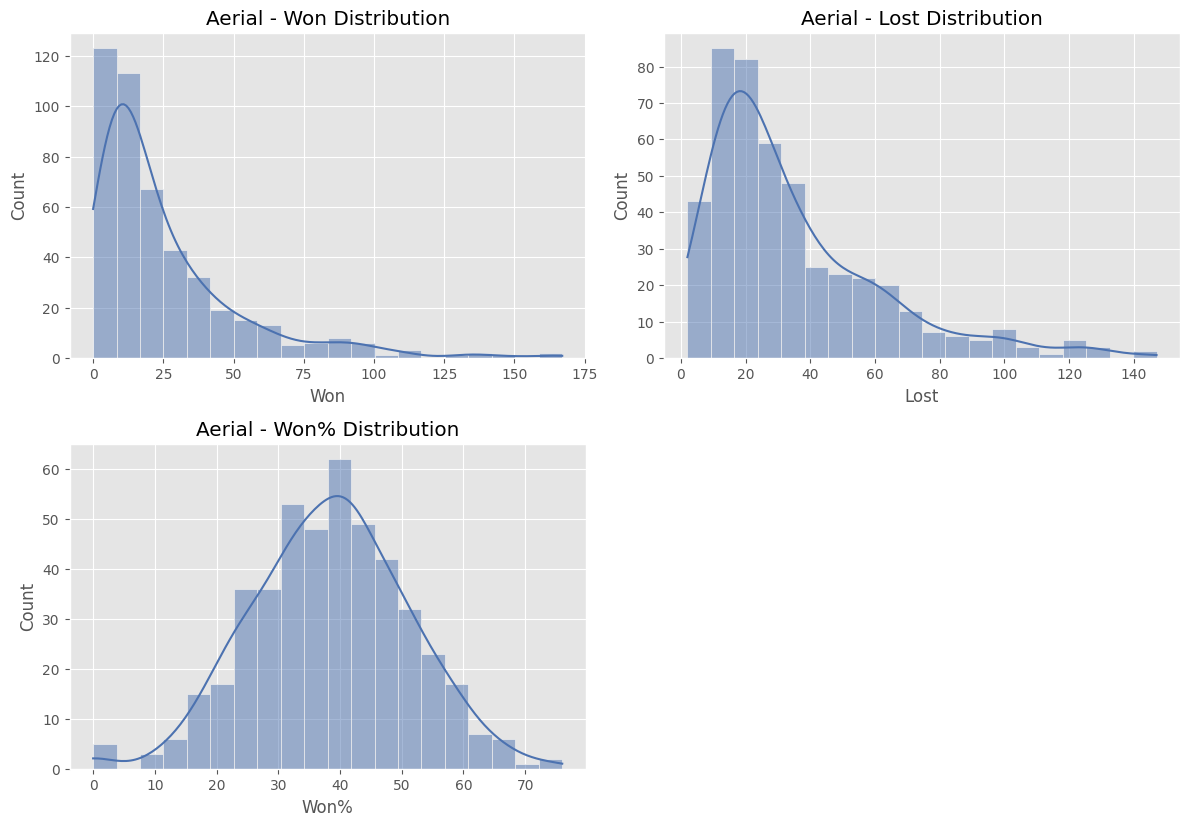

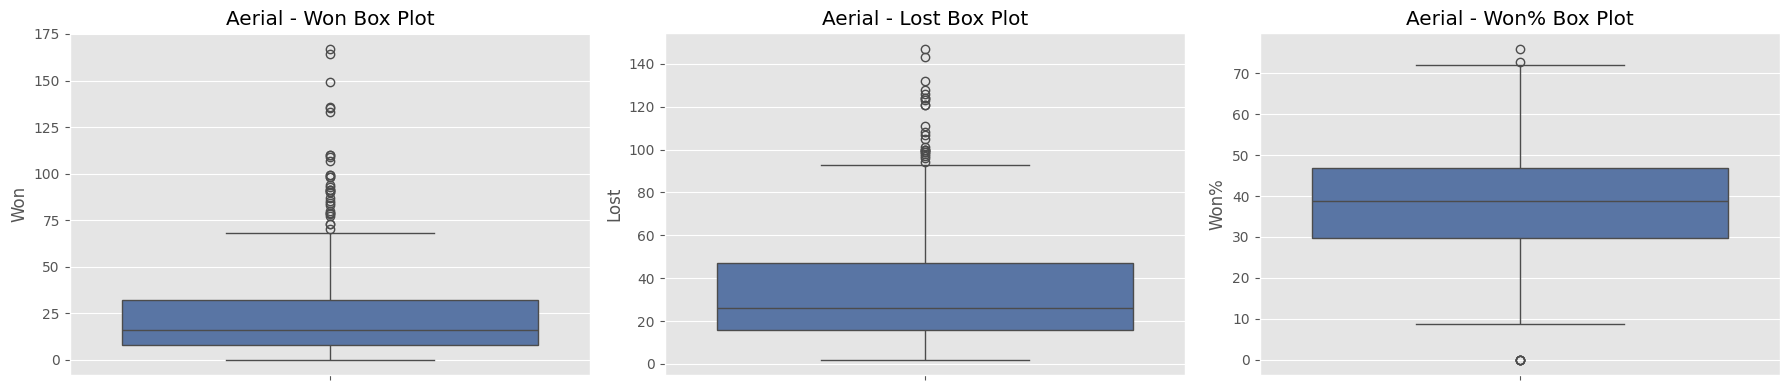


Plotting distributions for Defence with features: ['Tkl', 'TklW', 'Tkl%']


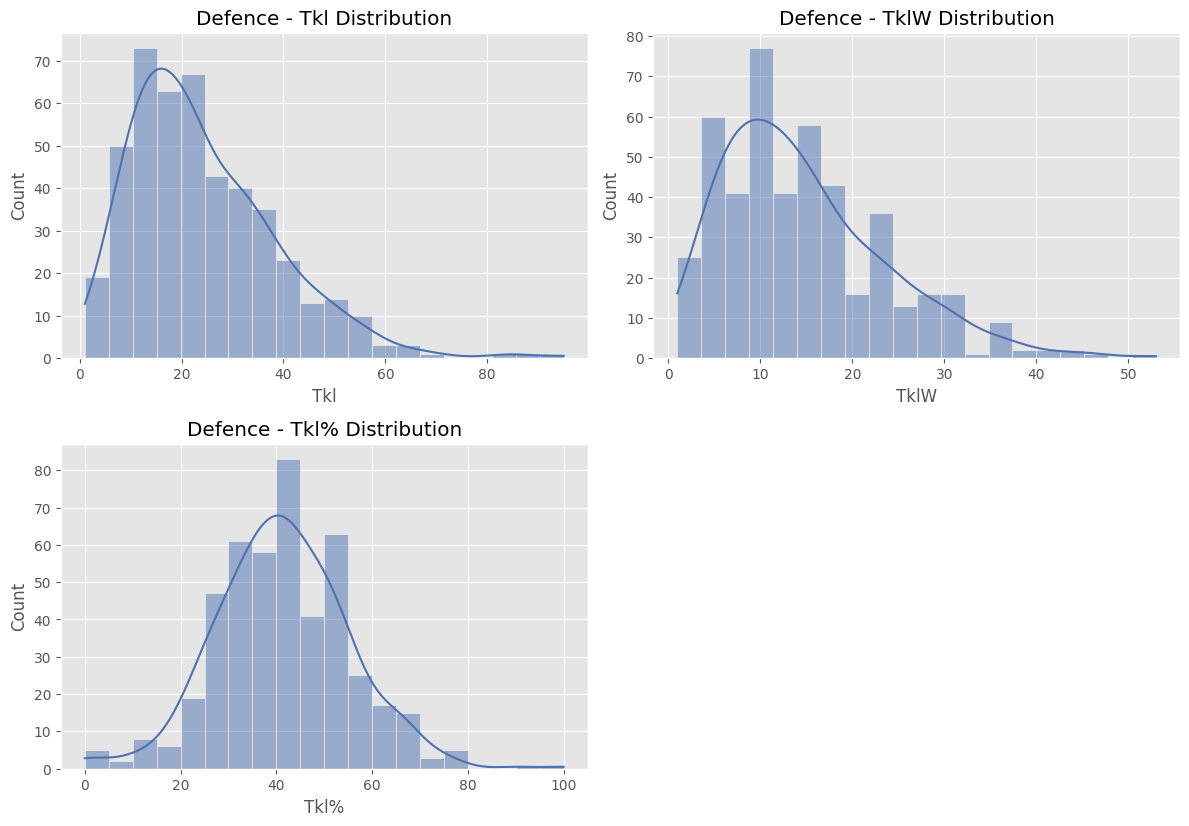

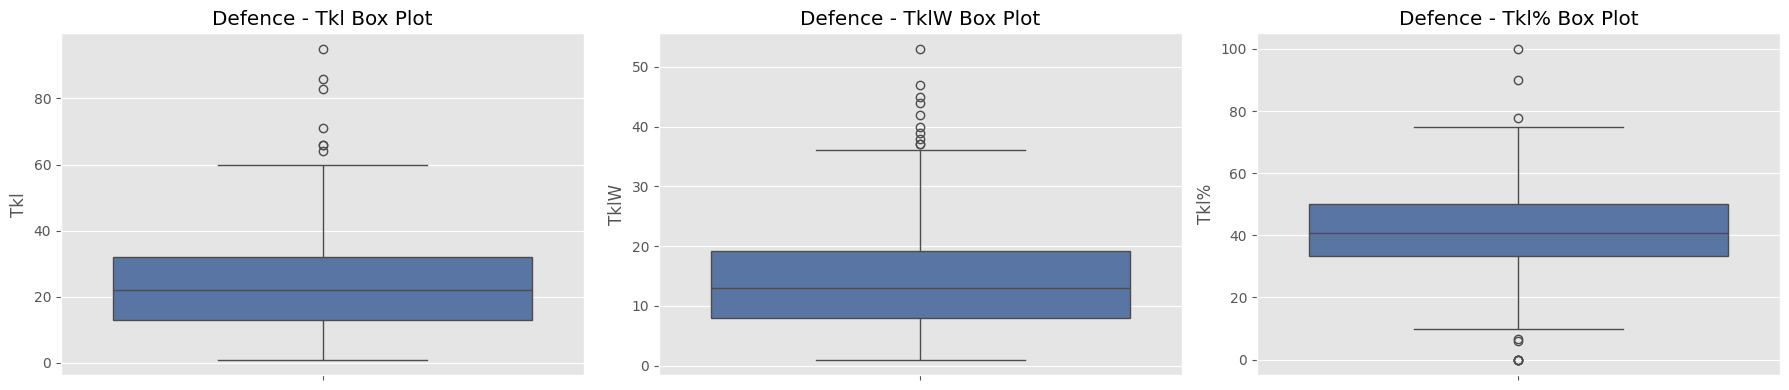


Plotting distributions for Goals with features: ['Goals', 'Non_Penalty_Goals', 'Goals_Assists']


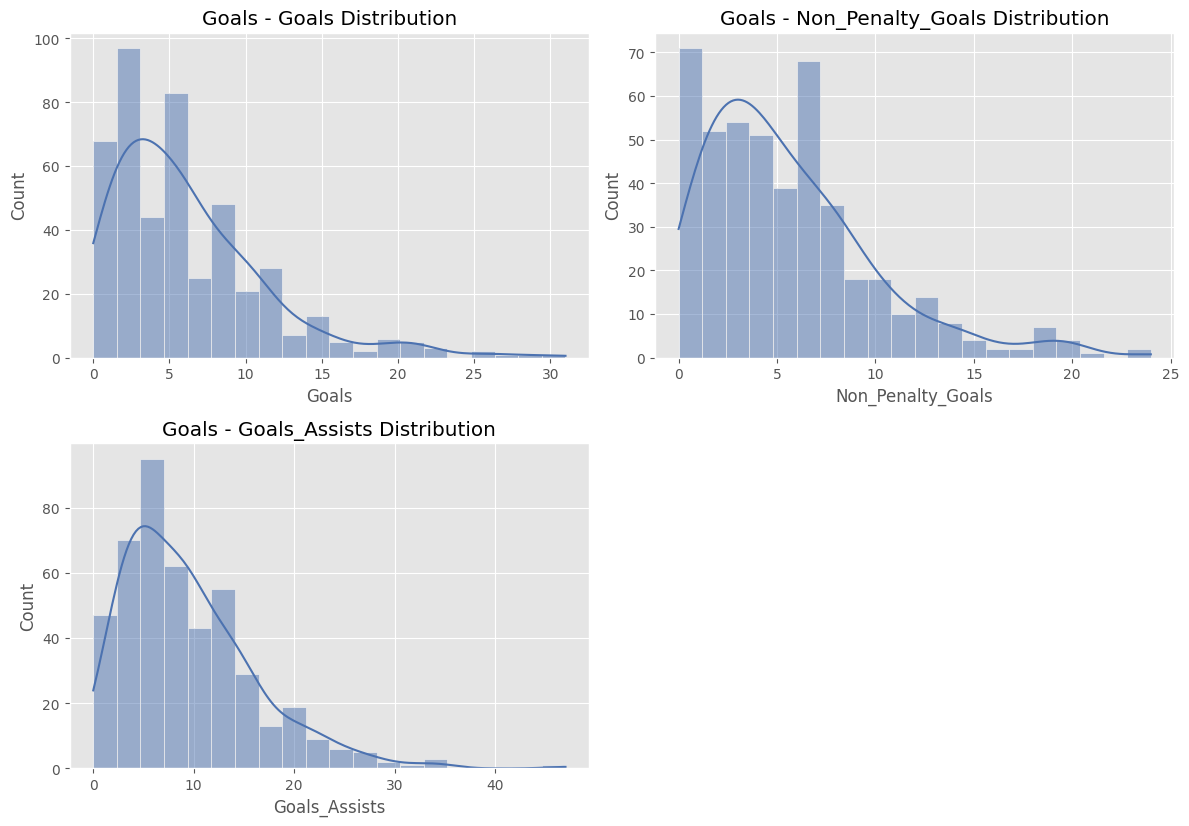

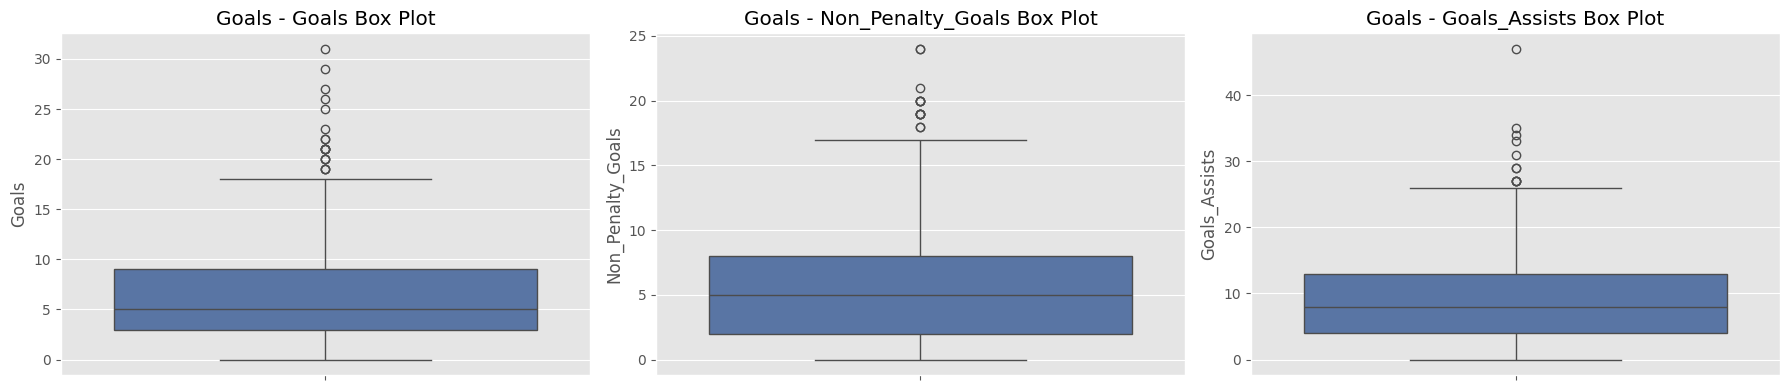


Plotting distributions for Passing with features: ['Att_Total', 'Cmp_Total', 'Cmp%_Total']


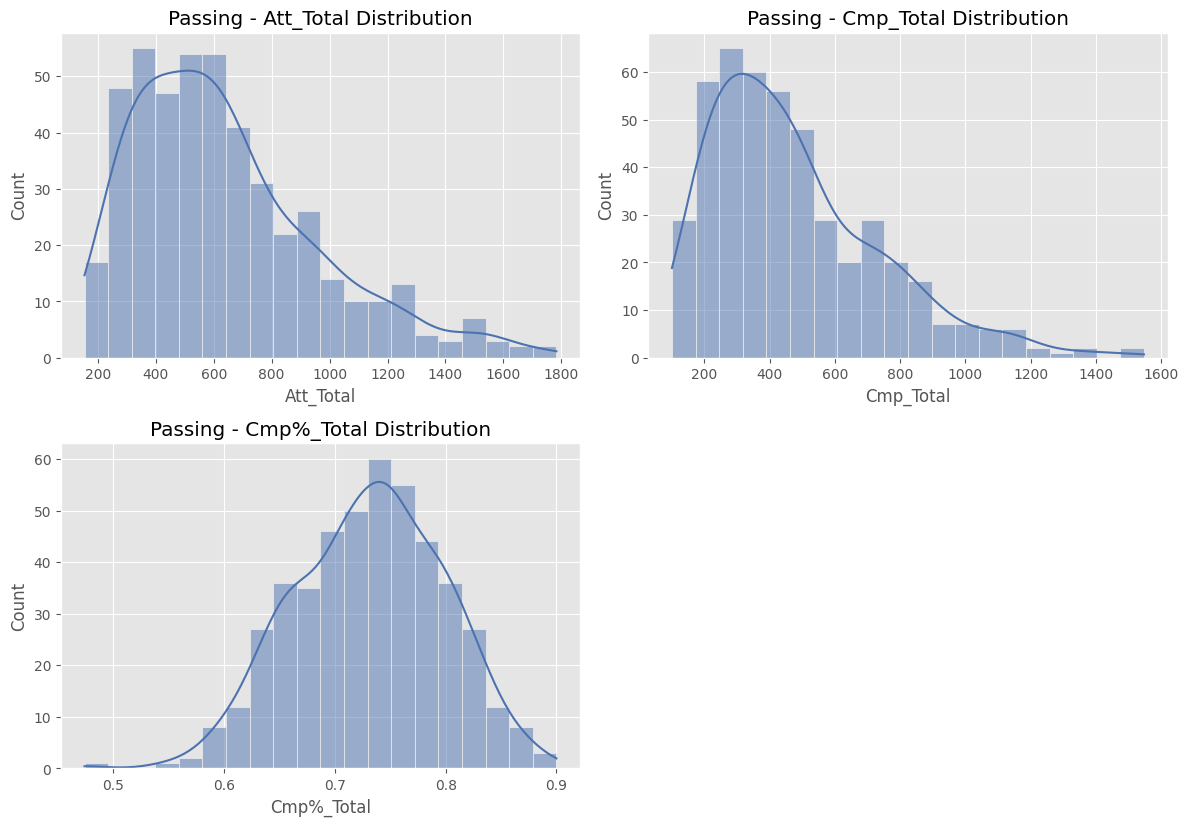

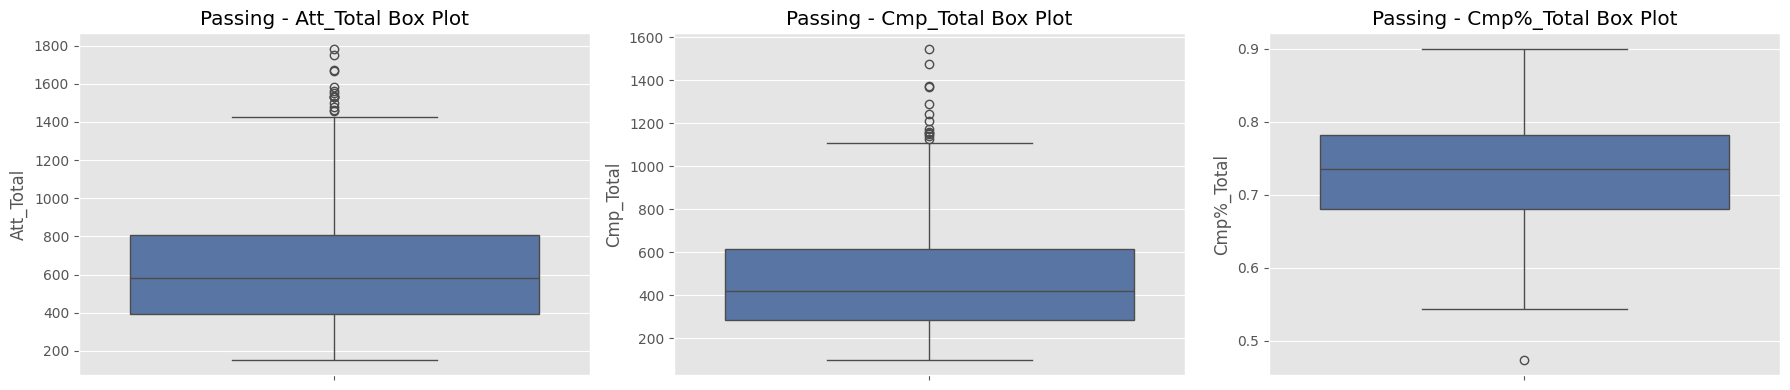


Plotting distributions for Takeons with features: ['Att', 'Succ', 'Succ%']


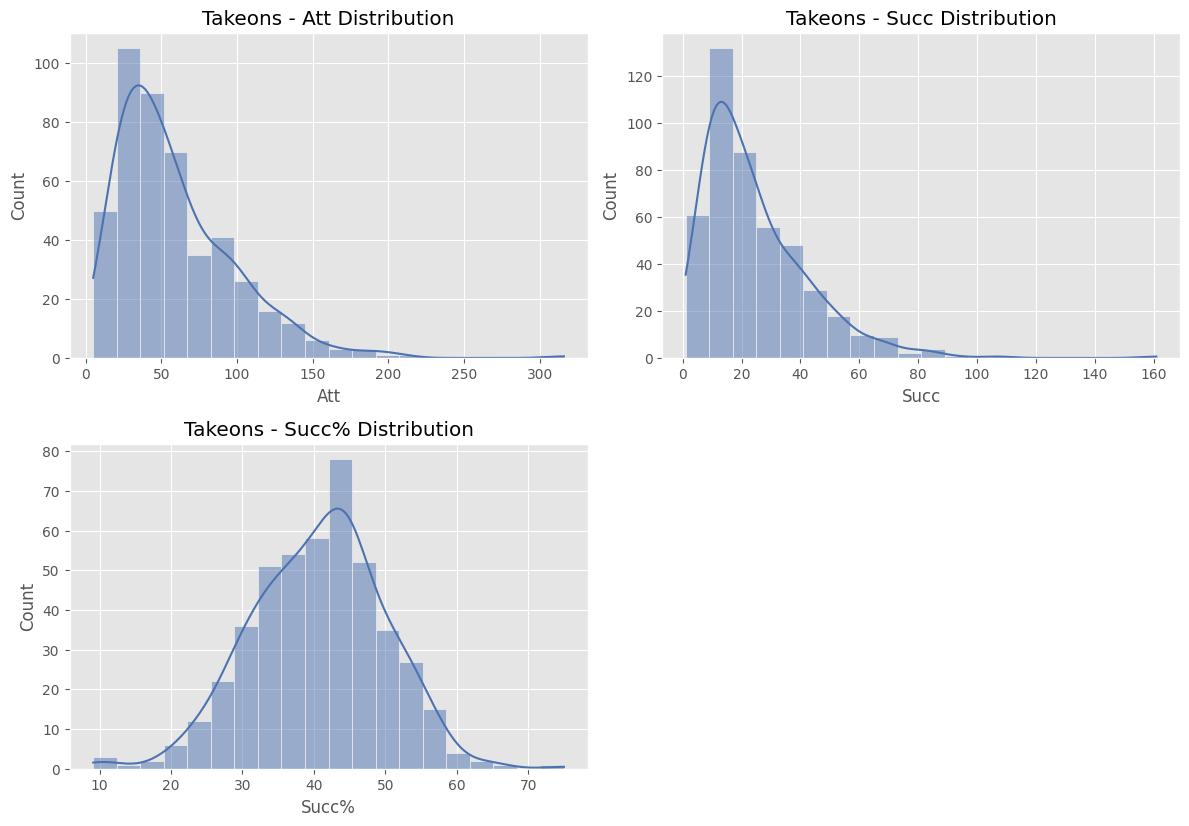

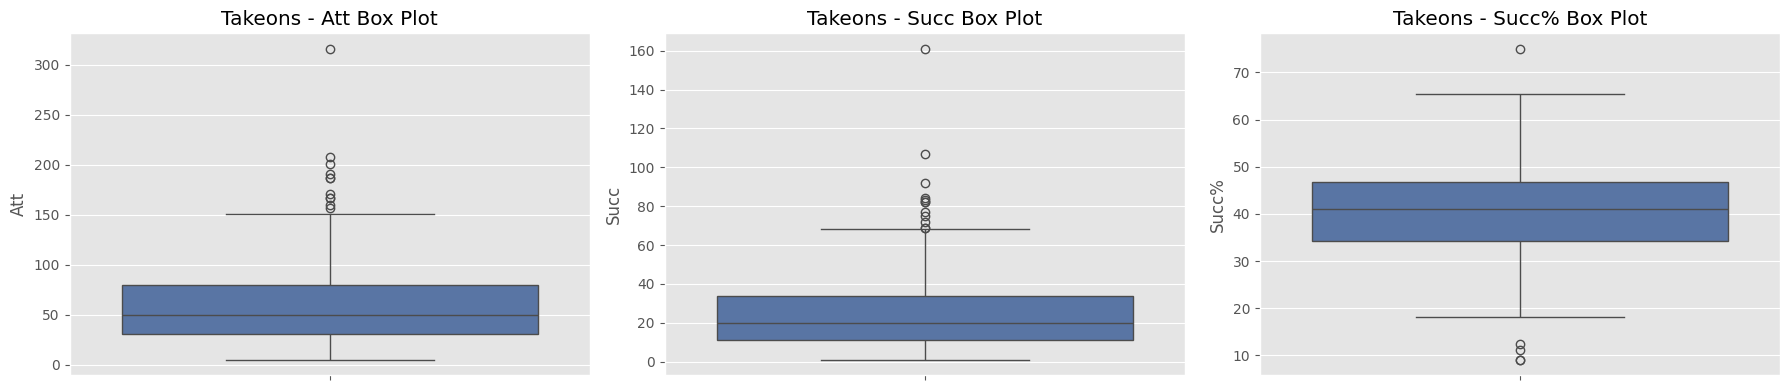


Plotting distributions for Shooting with features: ['Shots_Total', 'Shots_on_Target', 'Goals_per_Shot_on_Target']


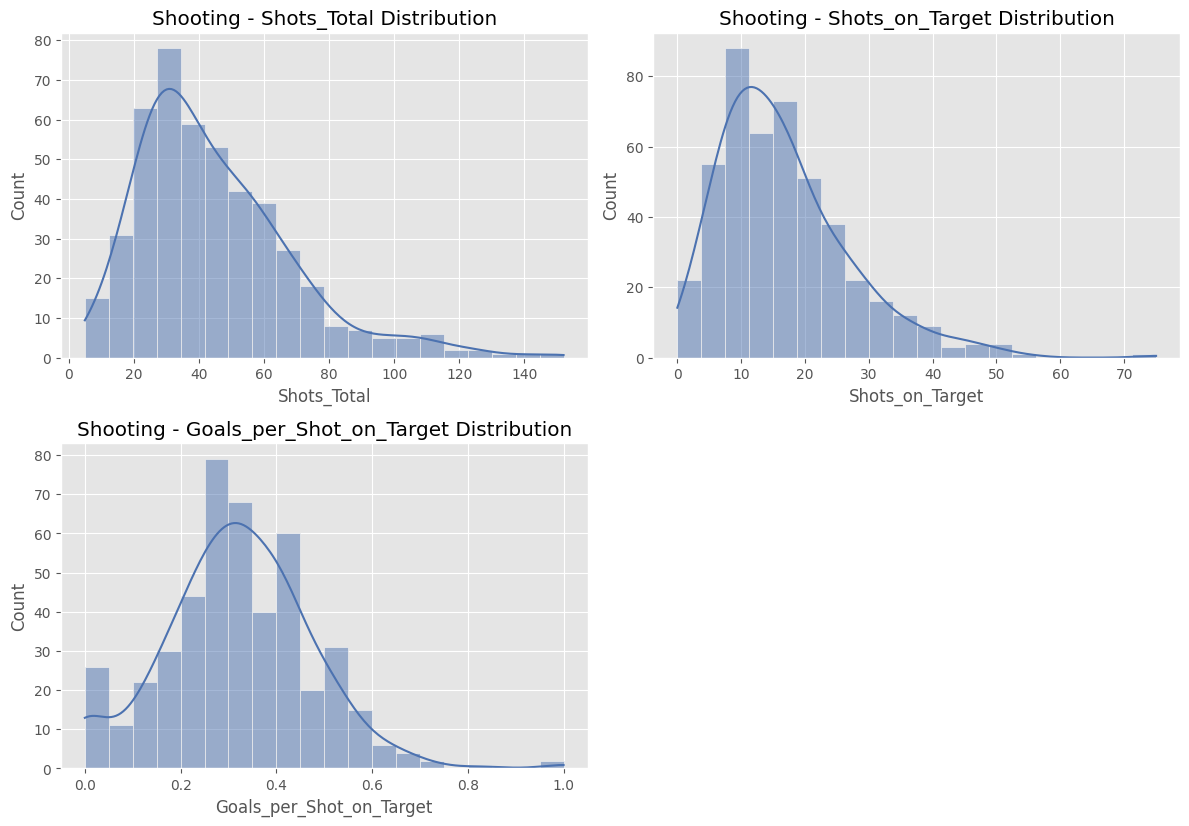

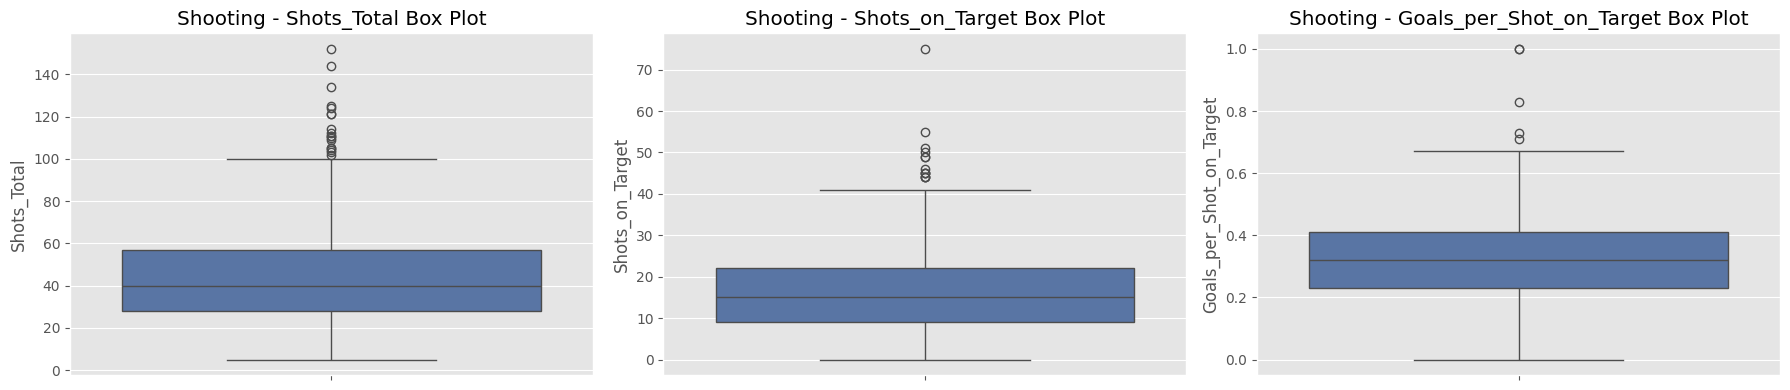


Plotting distributions for xG with features: ['xG', 'npxG']


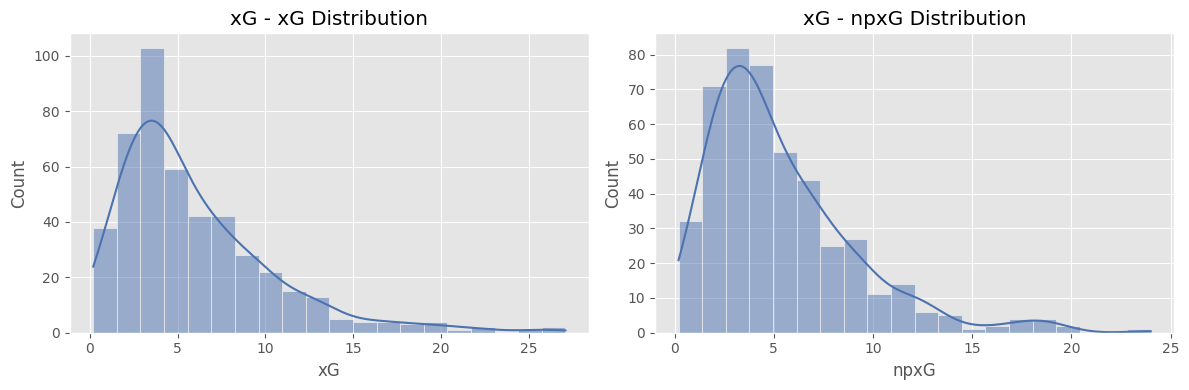

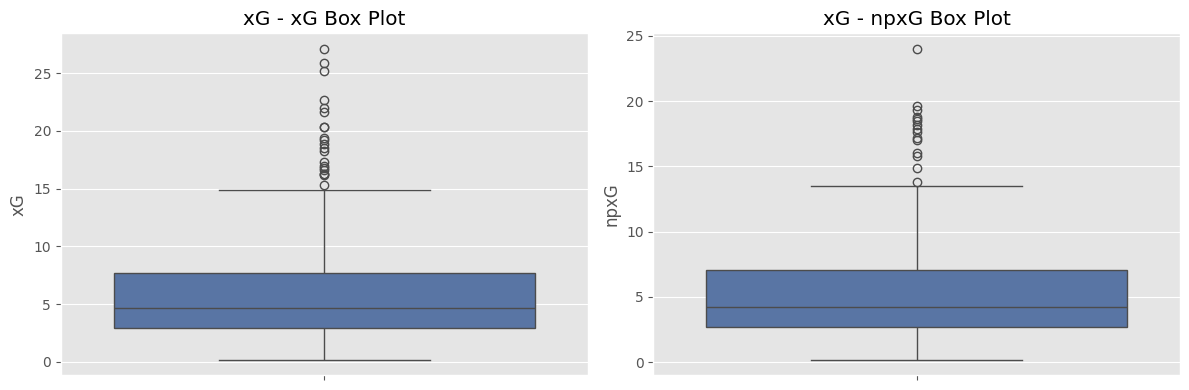


Plotting distributions for SCA with features: ['SCA', 'PassLive']


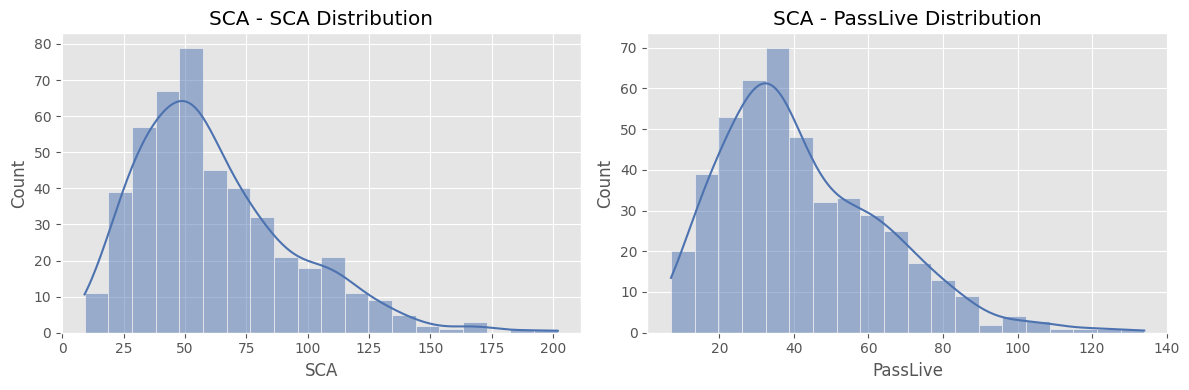

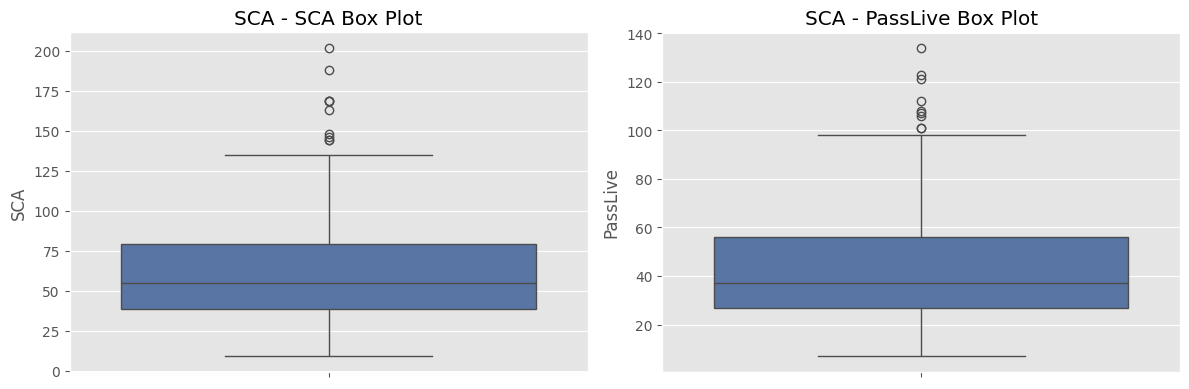


Plotting distributions for GCA with features: ['GCA', 'PassLive']


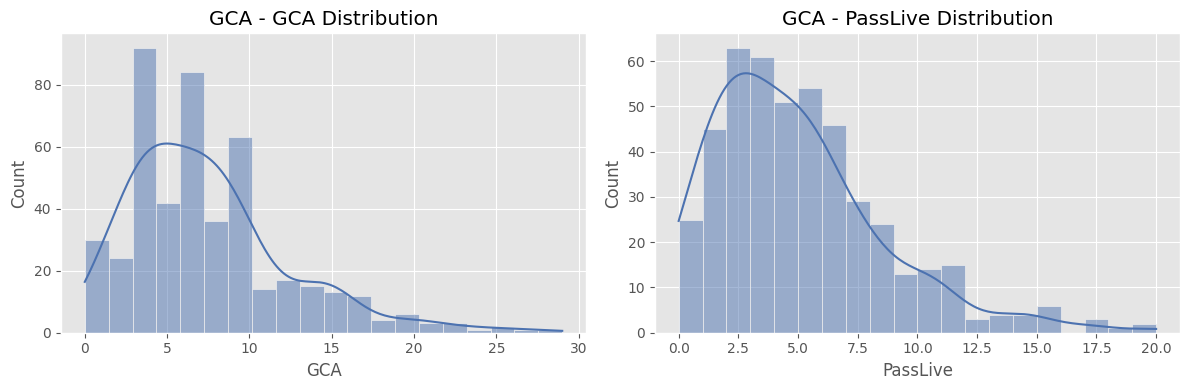

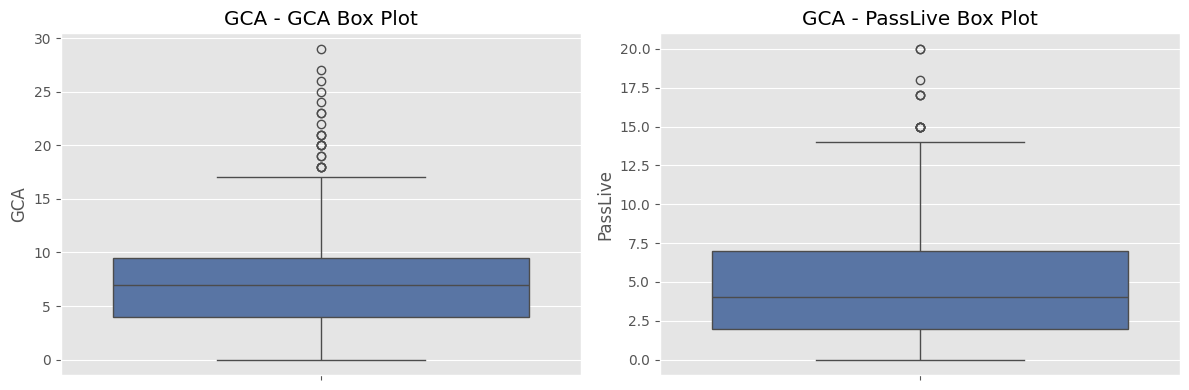


Plotting distributions for Carries with features: ['Carries', 'PrgC']


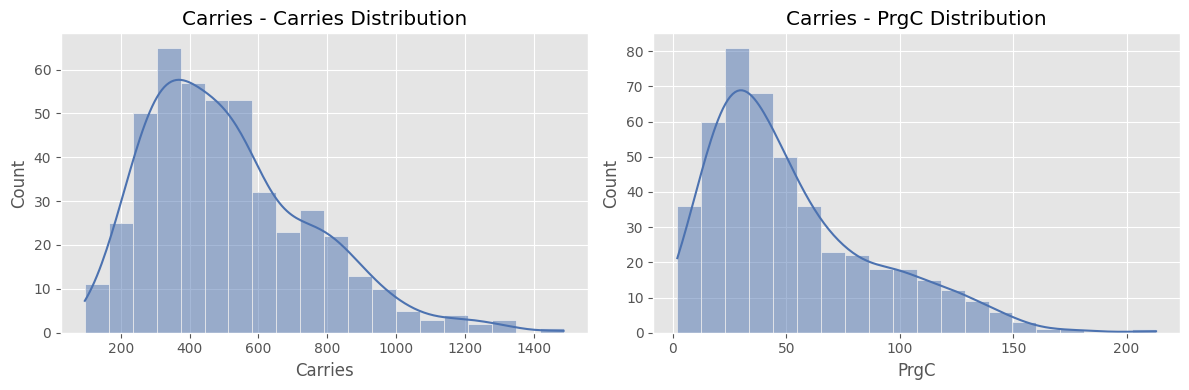

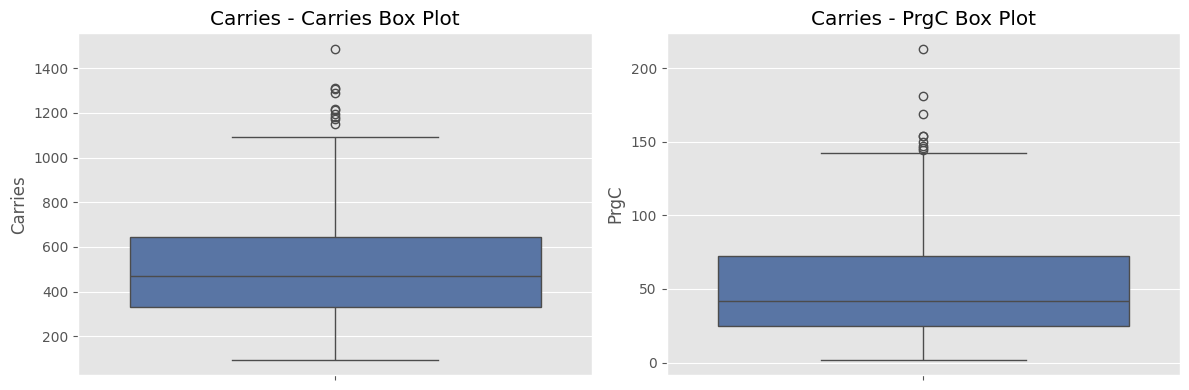


Plotting distributions for Touches with features: ['Touches', 'Att 3rd']


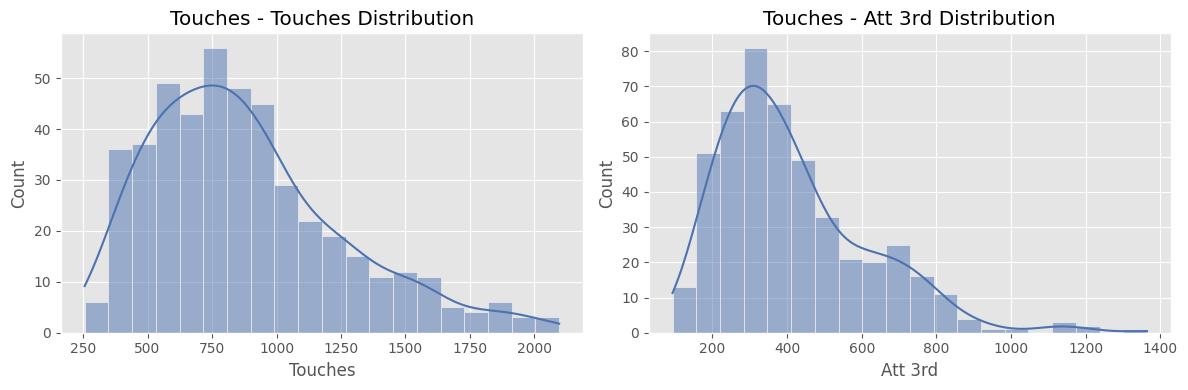

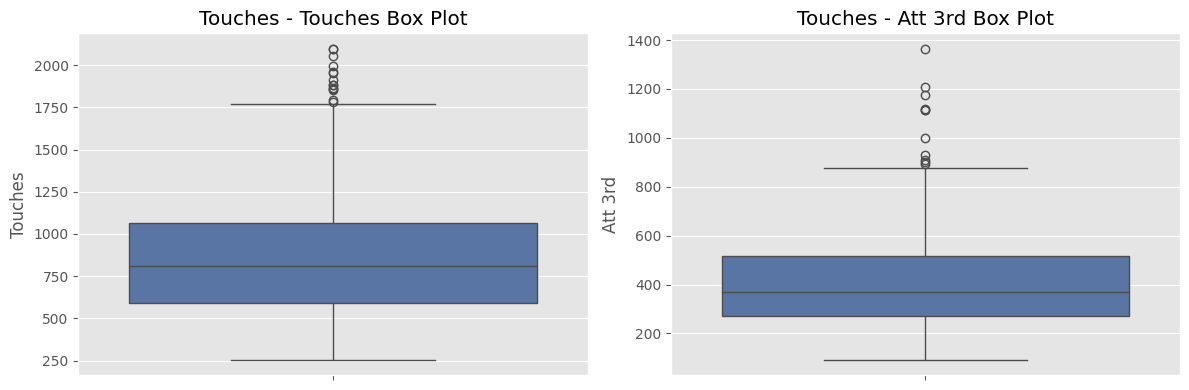

In [ ]:
def plot_distributions(df, category, features):
    available_features = [f for f in features if f in df.columns]
    if not available_features:
        print(f"No valid features found for {category}. Skipping distribution plots.")
        return
    n_features = len(available_features)
    n_cols = 2
    n_rows = (n_features + 1) // n_cols + (n_features % n_cols > 0)
    plt.figure(figsize=(12, 4 * n_rows))

    for i, feature in enumerate(available_features, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data=df, x=feature, bins=20, kde=True)
        plt.title(f'{category} - {feature} Distribution')
        plt.xlabel(feature)
        plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6 * n_features, 4))
    for i, feature in enumerate(available_features, 1):
        plt.subplot(1, n_features, i)
        sns.boxplot(data=df, y=feature)
        plt.title(f'{category} - {feature} Box Plot')
    plt.tight_layout()
    plt.show()

feature_mapping = {
    'Aerial': ['Won', 'Lost', 'Won%'],
    'Defence': ['Tkl', 'TklW', 'Tkl%'],
    'Goals': ['Goals', 'Non_Penalty_Goals', 'Goals_Assists'],
    'Passing': ['Att_Total', 'Cmp_Total', 'Cmp%_Total'],
    'Takeons': ['Att', 'Succ', 'Succ%'],
    'Shooting': ['Shots_Total', 'Shots_on_Target', 'Goals_per_Shot_on_Target'],
    'xG': ['xG', 'npxG'],
    'SCA': ['SCA', 'PassLive'],
    'GCA': ['GCA', 'PassLive'],
    'Carries': ['Carries', 'PrgC'],
    'Touches': ['Touches', 'Att 3rd']
}

for category, features in feature_mapping.items():
    print(f"\nPlotting distributions for {category} with features: {features}")
    plot_distributions(all_dfs[category], category, features)


Plotting correlation heatmap for Aerial with features: ['Won', 'Lost', 'Won%']


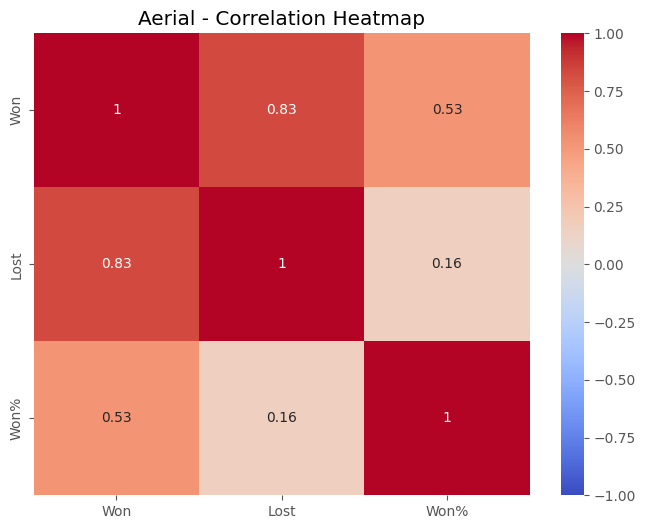


Plotting correlation heatmap for Defence with features: ['Tkl', 'TklW', 'Tkl%']


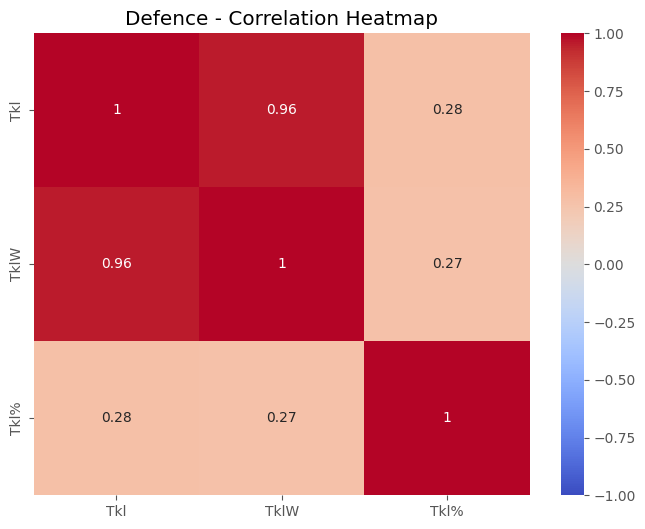


Plotting correlation heatmap for Goals with features: ['Goals', 'Non_Penalty_Goals', 'Goals_Assists']


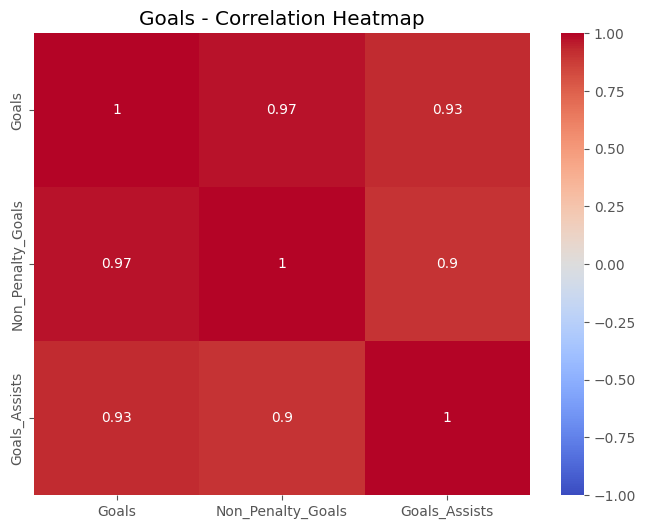


Plotting correlation heatmap for Passing with features: ['Att_Total', 'Cmp_Total', 'Cmp%_Total']


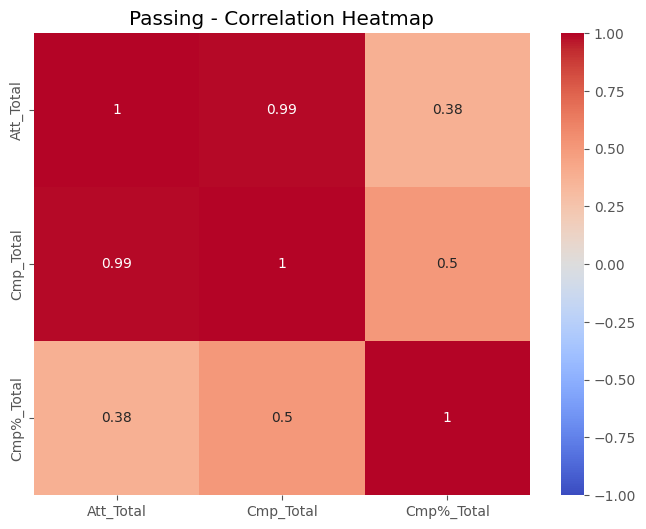


Plotting correlation heatmap for Takeons with features: ['Att', 'Succ', 'Succ%']


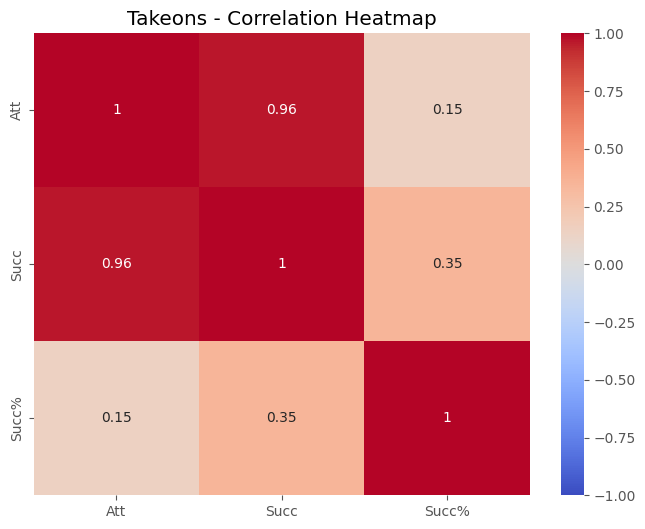


Plotting correlation heatmap for Shooting with features: ['Shots_Total', 'Shots_on_Target', 'Goals_per_Shot_on_Target']


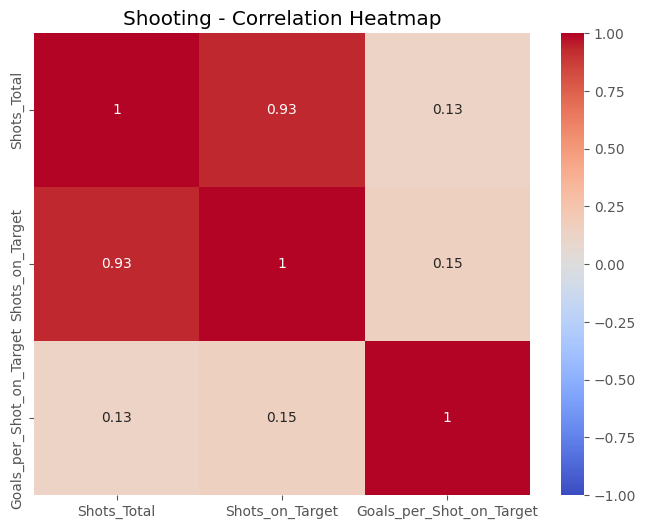


Plotting correlation heatmap for xG with features: ['xG', 'npxG']


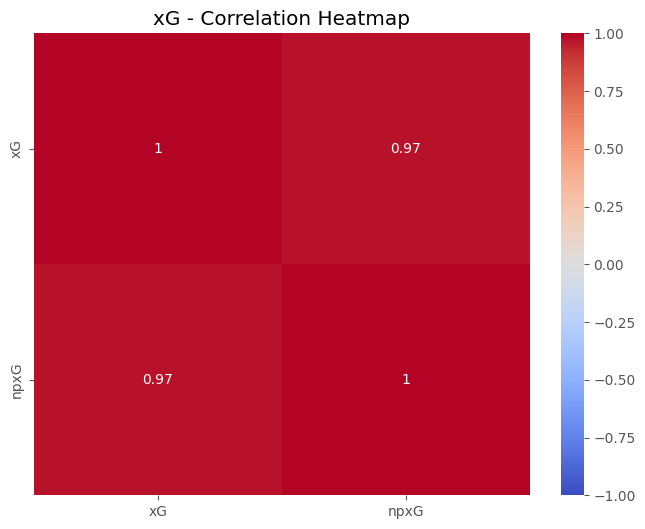


Plotting correlation heatmap for SCA with features: ['SCA', 'PassLive']


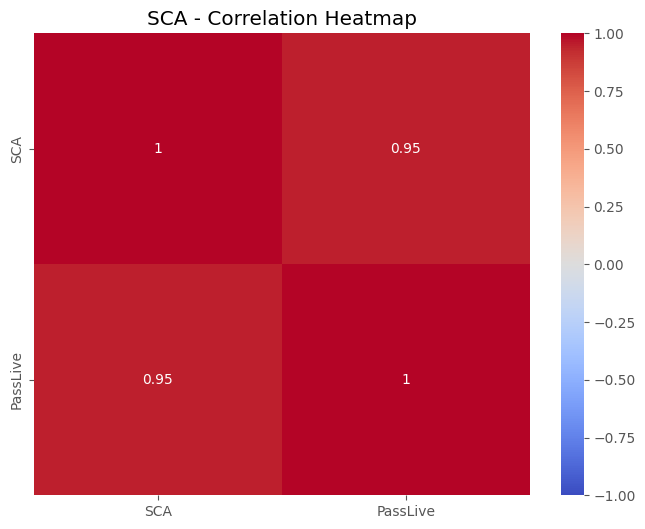


Plotting correlation heatmap for GCA with features: ['GCA', 'PassLive']


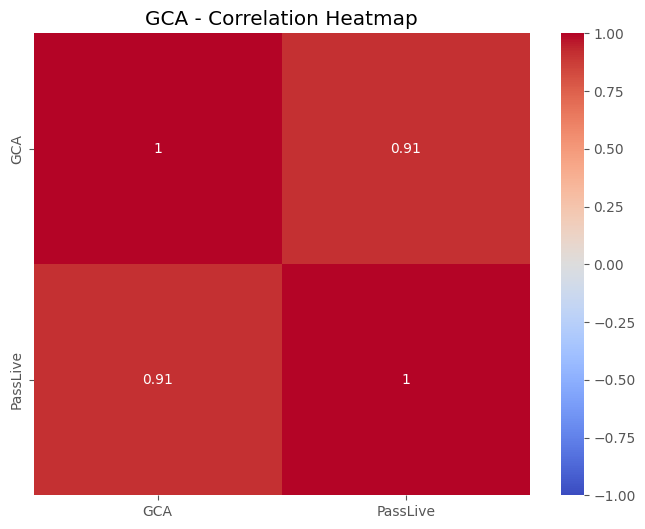


Plotting correlation heatmap for Carries with features: ['Carries', 'PrgC']


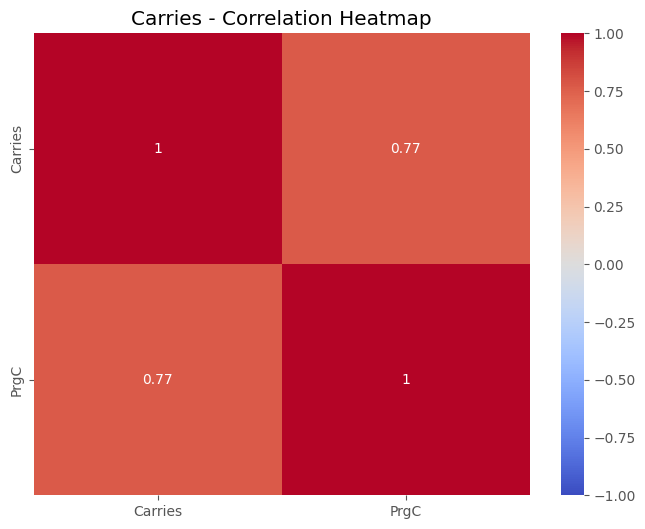


Plotting correlation heatmap for Touches with features: ['Touches', 'Att 3rd']


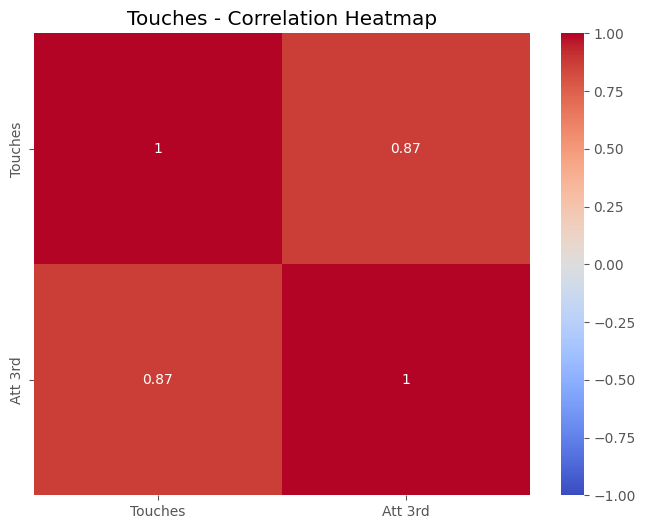

In [ ]:
def plot_correlation_heatmap(df, category, features):
    available_features = [f for f in features if f in df.columns]
    if not available_features:
        print(f"No valid features found for {category}. Skipping correlation heatmap.")
        return
    corr = df[available_features].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
    plt.title(f'{category} - Correlation Heatmap')
    plt.show()

for category, features in feature_mapping.items():
    print(f"\nPlotting correlation heatmap for {category} with features: {features}")
    plot_correlation_heatmap(all_dfs[category], category, features)

In [ ]:
def detect_outliers(df, feature):
    if feature not in df.columns:
        print(f"Feature {feature} not found in dataset. Skipping outlier detection.")
        return
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][['Player', feature]]
    print(f"\n{feature} Outliers ({len(outliers)}):")
    print(outliers)
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

for category, features in feature_mapping.items():
    print(f"\nOutlier Detection for {category}:")
    for feature in features:
        detect_outliers(all_dfs[category], feature)


Outlier Detection for Aerial:

Won Outliers (33):
                    Player  Won
2              Milan Đurić  167
3            Thierno Barry   99
6        Alexander Sørloth   98
9         Christian Kouamé   77
14            Paul Onuachu   93
15           Juanmi Latasa   90
17            Issa Soumaré   84
25          Benjamin Šeško   70
27            Vedat Muriqi  135
34             Lucas Höler   80
35         Philipp Hofmann  164
44         Tim Kleindienst  149
50         Bertuğ Yıldırım   73
51           Toni Martínez   79
58            Kevin Schade   90
59         Serhou Guirassy  109
62         Ludovic Ajorque  133
63                    Kiké  110
64          Morten Thorsby  107
72   Dominic Calvert-Lewin   85
74            Ante Budimir  136
86              Jonas Wind   98
95                    Beto   99
99         Oliver McBurnie   87
106          Phillip Tietz   78
107           Raúl Jiménez   91
114        Daniel Mosquera   79
164       Andrea Pinamonti   83
165        Roberto Pi

In [ ]:
for category in categories:
    missing_count = all_dfs[category].isnull().sum().sum()
    print(f"{category} Dataset - Missing Values: {missing_count}")

unique_player_counts = {category: len(df) for category, df in all_dfs.items()}
print("\nUnique Player Counts per Category:")
print(unique_player_counts)

Aerial Dataset - Missing Values: 0
Carries Dataset - Missing Values: 0
Defence Dataset - Missing Values: 0
GCA Dataset - Missing Values: 0
Goals Dataset - Missing Values: 0
Passing Dataset - Missing Values: 0
SCA Dataset - Missing Values: 0
Shooting Dataset - Missing Values: 2
Takeons Dataset - Missing Values: 0
Touches Dataset - Missing Values: 0
xG Dataset - Missing Values: 0

Unique Player Counts per Category:
{'Aerial': 460, 'Carries': 460, 'Defence': 460, 'GCA': 463, 'Goals': 460, 'Passing': 463, 'SCA': 463, 'Shooting': 463, 'Takeons': 460, 'Touches': 460, 'xG': 460}


In [ ]:
reference_players = set(all_dfs['Goals']['Player_ID'])
print(f"Number of players in reference (Goals): {len(reference_players)}")

for category in categories:
    if category != 'Goals':
        all_dfs[category] = all_dfs[category][all_dfs[category]['Player_ID'].isin(reference_players)]
        print(f"Number of players in {category} after alignment: {len(all_dfs[category])}")

unique_player_counts = {category: len(df) for category, df in all_dfs.items()}
print("\nUnique Player Counts per Category After Alignment:")
print(unique_player_counts)

all_dfs['Shooting'] = all_dfs['Shooting'].fillna(0)
print("\nMissing Values in Shooting After Filling:")
print(all_dfs['Shooting'].isnull().sum().sum())

Number of players in reference (Goals): 460
Number of players in Aerial after alignment: 460
Number of players in Carries after alignment: 460
Number of players in Defence after alignment: 460
Number of players in GCA after alignment: 460
Number of players in Passing after alignment: 460
Number of players in SCA after alignment: 460
Number of players in Shooting after alignment: 460
Number of players in Takeons after alignment: 460
Number of players in Touches after alignment: 460
Number of players in xG after alignment: 460

Unique Player Counts per Category After Alignment:
{'Aerial': 460, 'Carries': 460, 'Defence': 460, 'GCA': 460, 'Goals': 460, 'Passing': 460, 'SCA': 460, 'Shooting': 460, 'Takeons': 460, 'Touches': 460, 'xG': 460}

Missing Values in Shooting After Filling:
0


In [ ]:
for category in all_dfs.keys():
    if category != 'Goals':
        all_dfs[category] = all_dfs[category].merge(
            all_dfs['Goals'][['Player_ID', '90s']],
            on='Player_ID',
            how='left'
        )

all_dfs['Goals']['Gls_per90'] = all_dfs['Goals']['Goals'].div(all_dfs['Goals']['90s'].replace(0, 1))
all_dfs['Goals']['OffensiveImpact'] = (all_dfs['Goals']['Goals'] + all_dfs['Goals']['Assists']).div(all_dfs['Goals']['90s'].replace(0, 1))
print("Motivation: Gls_per90 and OffensiveImpact normalize and combine goals/assists by playing time (e.g., Mbappé's 31 goals).")

all_dfs['Aerial']['Won_per90'] = all_dfs['Aerial']['Won'].div(all_dfs['Aerial']['90s'].replace(0, 1))
all_dfs['Aerial']['Lost_per90'] = all_dfs['Aerial']['Lost'].div(all_dfs['Aerial']['90s'].replace(0, 1))
all_dfs['Aerial']['AerialEff'] = (all_dfs['Aerial']['Won'] / (all_dfs['Aerial']['Won'] + all_dfs['Aerial']['Lost'])) * 100
all_dfs['Aerial']['AerialImpact'] = all_dfs['Aerial']['Won_per90'] * (all_dfs['Aerial']['AerialEff'] / 100)
print("Motivation: Aerial metrics normalize duels and combine frequency/efficiency (e.g., Đurić’s 167 wins).")

all_dfs['Defence']['Tkl_per90'] = all_dfs['Defence']['Tkl'].div(all_dfs['Defence']['90s'].replace(0, 1))
all_dfs['Defence']['TklW_per90'] = all_dfs['Defence']['TklW'].div(all_dfs['Defence']['90s'].replace(0, 1))
all_dfs['Defence']['DefImpact'] = (all_dfs['Defence']['TklW_per90'] * all_dfs['Defence']['Tkl%']) / 100
print("Motivation: Defence metrics normalize tackles and assess impact (e.g., Bischof’s 95 tackles).")

all_dfs['Passing']['Pass_Att_per90'] = all_dfs['Passing']['Att_Total'].div(all_dfs['Passing']['90s'].replace(0, 1))
all_dfs['Passing']['Pass_Cmp_per90'] = all_dfs['Passing']['Cmp_Total'].div(all_dfs['Passing']['90s'].replace(0, 1))
all_dfs['Passing']['PassImpact'] = all_dfs['Passing']['Pass_Cmp_per90'] * (all_dfs['Passing']['Cmp%_Total'] / 100)
print("Motivation: Passing metrics normalize and combine volume/accuracy.")

all_dfs['Takeons']['Takeons_Att_per90'] = all_dfs['Takeons']['Att'].div(all_dfs['Takeons']['90s'].replace(0, 1))
all_dfs['Takeons']['Takeons_Succ_per90'] = all_dfs['Takeons']['Succ'].div(all_dfs['Takeons']['90s'].replace(0, 1))
all_dfs['Takeons']['TakeonImpact'] = all_dfs['Takeons']['Takeons_Succ_per90'] * (all_dfs['Takeons']['Succ%'] / 100)
print("Motivation: Takeon metrics normalize and combine attempts/success.")

all_dfs['Shooting']['Sh_per90'] = all_dfs['Shooting']['Shots_Total'].div(all_dfs['Shooting']['90s'].replace(0, 1))
all_dfs['Shooting']['SoT_per90'] = all_dfs['Shooting']['Shots_on_Target'].div(all_dfs['Shooting']['90s'].replace(0, 1))
print("Motivation: Shooting metrics normalize shots by playing time.")

all_dfs['xG']['xG_per90'] = all_dfs['xG']['xG'].div(all_dfs['xG']['90s'].replace(0, 1))
all_dfs['xG']['npxG_per90'] = all_dfs['xG']['npxG'].div(all_dfs['xG']['90s'].replace(0, 1))
print("Motivation: xG metrics normalize expected goals by playing time.")

all_dfs['SCA']['SCA_per90'] = all_dfs['SCA']['SCA'].div(all_dfs['SCA']['90s'].replace(0, 1))
all_dfs['SCA']['SCA_PassLive_per90'] = all_dfs['SCA']['PassLive'].div(all_dfs['SCA']['90s'].replace(0, 1))
print("Motivation: SCA metrics normalize shot-creating actions by playing time.")

all_dfs['GCA']['GCA_per90'] = all_dfs['GCA']['GCA'].div(all_dfs['GCA']['90s'].replace(0, 1))
all_dfs['GCA']['GCA_PassLive_per90'] = all_dfs['GCA']['PassLive'].div(all_dfs['GCA']['90s'].replace(0, 1))
print("Motivation: GCA metrics normalize goal-creating actions by playing time.")

all_dfs['Carries']['Carries_per90'] = all_dfs['Carries']['Carries'].div(all_dfs['Carries']['90s'].replace(0, 1))
all_dfs['Carries']['ProgCarries_per90'] = all_dfs['Carries']['PrgC'].div(all_dfs['Carries']['90s'].replace(0, 1))
print("Motivation: Carries metrics normalize ball progression by playing time.")

all_dfs['Touches']['Touches_per90'] = all_dfs['Touches']['Touches'].div(all_dfs['Touches']['90s'].replace(0, 1))
all_dfs['Touches']['Att_3rd_Touches_per90'] = all_dfs['Touches']['Att 3rd'].div(all_dfs['Touches']['90s'].replace(0, 1))
print("Motivation: Touches metrics normalize involvement by playing time.")

print("\nSample of Engineered Features:")
for category in categories:
    print(f"\n{category} Dataset:")
    if category == 'Goals':
        print(all_dfs[category][['Player_ID', 'Player', 'Gls_per90', 'OffensiveImpact']].head(1))
    elif category == 'Aerial':
        print(all_dfs[category][['Player_ID', 'Player', 'Won_per90', 'Lost_per90', 'AerialEff', 'AerialImpact']].head(1))
    elif category == 'Defence':
        print(all_dfs[category][['Player_ID', 'Player', 'Tkl_per90', 'TklW_per90', 'DefImpact']].head(1))
    elif category == 'Passing':
        print(all_dfs[category][['Player_ID', 'Player', 'Pass_Att_per90', 'Pass_Cmp_per90', 'PassImpact']].head(1))
    elif category == 'Takeons':
        print(all_dfs[category][['Player_ID', 'Player', 'Takeons_Att_per90', 'Takeons_Succ_per90', 'TakeonImpact']].head(1))
    elif category == 'Shooting':
        print(all_dfs[category][['Player_ID', 'Player', 'Sh_per90', 'SoT_per90']].head(1))
    elif category == 'xG':
        print(all_dfs[category][['Player_ID', 'Player', 'xG_per90', 'npxG_per90']].head(1))
    elif category == 'SCA':
        print(all_dfs[category][['Player_ID', 'Player', 'SCA_per90', 'SCA_PassLive_per90']].head(1))
    elif category == 'GCA':
        print(all_dfs[category][['Player_ID', 'Player', 'GCA_per90', 'GCA_PassLive_per90']].head(1))
    elif category == 'Carries':
        print(all_dfs[category][['Player_ID', 'Player', 'Carries_per90', 'ProgCarries_per90']].head(1))
    elif category == 'Touches':
        print(all_dfs[category][['Player_ID', 'Player', 'Touches_per90', 'Att_3rd_Touches_per90']].head(1))

Motivation: Gls_per90 and OffensiveImpact normalize and combine goals/assists by playing time (e.g., Mbappé's 31 goals).
Motivation: Aerial metrics normalize duels and combine frequency/efficiency (e.g., Đurić’s 167 wins).
Motivation: Defence metrics normalize tackles and assess impact (e.g., Bischof’s 95 tackles).
Motivation: Passing metrics normalize and combine volume/accuracy.
Motivation: Takeon metrics normalize and combine attempts/success.
Motivation: Shooting metrics normalize shots by playing time.
Motivation: xG metrics normalize expected goals by playing time.
Motivation: SCA metrics normalize shot-creating actions by playing time.
Motivation: GCA metrics normalize goal-creating actions by playing time.
Motivation: Carries metrics normalize ball progression by playing time.
Motivation: Touches metrics normalize involvement by playing time.

Sample of Engineered Features:

Aerial Dataset:
  Player_ID           Player  Won_per90  Lost_per90  AerialEff  AerialImpact
0  481c9ece

In [ ]:
print("\n'all_dfs' dictionary is now prepared with engineered features for direct use in the final project code.")
print("Categories available in all_dfs:", list(all_dfs.keys()))
print("\nSample of key categories with engineered features:")
for category in ['Goals', 'Aerial', 'Defence', 'Passing', 'Takeons']:
    print(f"\n{category} Dataset:")
    if category == 'Goals':
        print(all_dfs[category][['Player_ID', 'Player', 'Gls_per90', 'OffensiveImpact']].head())
    elif category == 'Aerial':
        print(all_dfs[category][['Player_ID', 'Player', 'Won_per90', 'Lost_per90', 'AerialEff', 'AerialImpact']].head())
    elif category == 'Defence':
        print(all_dfs[category][['Player_ID', 'Player', 'Tkl_per90', 'TklW_per90', 'DefImpact']].head())
    elif category == 'Passing':
        print(all_dfs[category][['Player_ID', 'Player', 'Pass_Att_per90', 'Pass_Cmp_per90', 'PassImpact']].head())
    elif category == 'Takeons':
        print(all_dfs[category][['Player_ID', 'Player', 'Takeons_Att_per90', 'Takeons_Succ_per90', 'TakeonImpact']].head())

features_to_merge = {
    'Goals': ['Gls_per90', 'OffensiveImpact'],
    'Aerial': ['Won_per90', 'Lost_per90', 'AerialEff', 'AerialImpact'],
    'Defence': ['Tkl_per90', 'TklW_per90', 'DefImpact'],
    'Passing': ['Pass_Att_per90', 'Pass_Cmp_per90', 'PassImpact'],
    'Takeons': ['Takeons_Att_per90', 'Takeons_Succ_per90', 'TakeonImpact']
}

df_final = all_dfs['Goals'][['Player_ID', 'Player', 'Team', 'Position'] + features_to_merge['Goals']].copy()

for category in ['Aerial', 'Defence', 'Passing', 'Takeons']:
    df_final = df_final.merge(
        all_dfs[category][['Player_ID'] + features_to_merge[category]],
        on='Player_ID',
        how='inner'
    )

print("\nBaseline Dataset Shape (for testing improvements):", df_final.shape)
print("\nBaseline Dataset Info:")
print(df_final.info())
print("\nBaseline Dataset Head:")
print(df_final.head())

df_final.to_csv('player_data_for_clustering.csv', index=False)
print("\nSaved baseline dataset to 'player_data_for_clustering.csv' for testing improvements.")
print("Note: Your final code uses 'all_dfs' directly; this file is for experimentation only.")


'all_dfs' dictionary is now prepared with engineered features for direct use in the final project code.
Categories available in all_dfs: ['Aerial', 'Carries', 'Defence', 'GCA', 'Goals', 'Passing', 'SCA', 'Shooting', 'Takeons', 'Touches', 'xG']

Sample of key categories with engineered features:

Goals Dataset:
  Player_ID              Player  Gls_per90  OffensiveImpact
0  42fd9c7f       Kylian Mbappé   0.959752         1.052632
1  e342ad68       Mohamed Salah   0.773333         1.253333
2  8d78e732  Robert Lewandowski   0.912162         0.979730
3  21a66f6a          Harry Kane   0.981132         1.320755
4  e7695e6c       Mateo Retegui   0.943396         1.245283

Aerial Dataset:
  Player_ID               Player  Won_per90  Lost_per90  AerialEff  \
0  481c9ece      Denzel Dumfries   2.626728    0.829493  76.000000   
1  ee251371  Alexis Saelemaekers   0.487805    0.182927  72.727273   
2  405f6586          Milan Đurić   9.766082    3.801170  71.982759   
3  52c3244b        Thierno Bar

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

plt.style.use('ggplot')
sns.set_palette("deep")

In [ ]:
df = pd.read_csv('player_data_for_clustering.csv')
print("Baseline Dataset Shape:", df.shape)
print("\nBaseline Dataset Head:")
print(df.head())

Baseline Dataset Shape: (460, 19)

Baseline Dataset Head:
  Player_ID              Player           Team Position  Gls_per90  \
0  42fd9c7f       Kylian Mbappé    Real Madrid       FW   0.959752   
1  e342ad68       Mohamed Salah      Liverpool       FW   0.773333   
2  8d78e732  Robert Lewandowski      Barcelona       FW   0.912162   
3  21a66f6a          Harry Kane  Bayern Munich       FW   0.981132   
4  e7695e6c       Mateo Retegui       Atalanta       FW   0.943396   

   OffensiveImpact  Won_per90  Lost_per90  AerialEff  AerialImpact  Tkl_per90  \
0         1.052632   0.123839    0.185759  40.000000      0.049536   0.247678   
1         1.253333   0.240000    0.373333  39.130435      0.093913   0.560000   
2         0.979730   1.250000    1.317568  48.684211      0.608553   0.337838   
3         1.320755   1.094340    0.754717  59.183673      0.647670   0.490566   
4         1.245283   1.924528    2.566038  42.857143      0.824798   0.528302   

   TklW_per90  DefImpact  Pass_Att

In [ ]:
from google.colab import files

files.download('player_data_for_clustering.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>